# Lightweight Fine-Tuning Project

TODO: In this cell, describe your choices for each of the following

* PEFT technique: We are going to use LoRA and QLoRA techniques
* Model: This being a SequenceClassification task, we will use and compare one encoder based(roberta-base) and one decoder based model (gpt2). For GPT2, we will be doing full fine-tuning as well as LoRA/QLoRA fine tuning in different combination of ranks and quant bits. For roberta-base, we will be doing LoRA fine tuning with ranks 4, 8, 16
* Evaluation approach: We will use accuracy, F1-Score, Specificity and Precision Score
* Fine-tuning dataset: We will be using imdb dataset which is available on huggingface

In [2]:
!pip install -U accelerate
!pip install scikit-learn
!pip install seaborn
!pip install -U datasets
!pip install -U bitsandbytes
#Please restart kernel once these modules have been installed and continue from the next executable cell

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.0/280.0 kB 2.5 MB/s eta 0:00:0000:0100:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 59.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.2/302.2 kB 40.7 MB/s eta 0:00:00
Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 1.8 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 65.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.7/310.7 kB 46.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 93.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 330.1/330.1 kB 29.7 MB/s eta 0:00:00
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.0/105.0 MB 12.5 MB/s eta 0:00:0000:0100:01


In [2]:
!pip install -U transformers

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 371.6 kB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 471.0 kB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 1.4 MB/s eta 0:00:0000:0100:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [1]:
import torch
import torch.nn as nn
import datasets
from datasets import load_dataset
from datasets import Dataset
from transformers import BitsAndBytesConfig

/opt/conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import time
import datetime
from datetime import datetime

In [3]:
import numpy as np
import pandas as pd
import re, os, time
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import time

In [4]:
import transformers
from transformers import AutoModel, AutoModelForSequenceClassification, AutoTokenizer, DataCollatorWithPadding, Trainer, TrainingArguments

In [5]:
transformers.__version__

'4.38.1'

In [6]:
!pip install torchinfo

Defaulting to user installation because normal site-packages is not writeable


In [7]:
from torchinfo import summary

In [8]:
!pip install loralib
!pip install peft
!pip install evaluate

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 888.8 kB/s eta 0:00:00 0:00:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [9]:
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, TaskType, PeftConfig, PeftModel,AutoPeftModelForSequenceClassification 

## Loading and Evaluating a Foundation Model

TODO: In the cells below, load your chosen pre-trained Hugging Face model and evaluate its performance prior to fine-tuning. This step includes loading an appropriate tokenizer and dataset.

In [9]:
#let us see how dataset looks like and whether it is class balanced

In [10]:
ds = load_dataset("imdb", split="train")

Generating unsupervised split: 100%|██████████| 50000/50000 [00:00<00:00, 106943.48 examples/s]


In [11]:
ds

Dataset({
    features: ['text', 'label'],
    num_rows: 25000
})

In [12]:
df_imdb = pd.DataFrame(ds[0:])

In [13]:
df_imdb.head()

,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


In [14]:
df_imdb['length_text'] = df_imdb['text'].apply(lambda x: len(x.split()))

In [15]:
df_imdb

,text,label,length_text
0,I rented I AM CURIOUS-YELLOW from my video sto...,0,288
1,"""I Am Curious: Yellow"" is a risible and preten...",0,214
2,If only to avoid making this type of film in t...,0,93
3,This film was probably inspired by Godard's Ma...,0,118
4,"Oh, brother...after hearing about this ridicul...",0,311
...,...,...,...
24995,A hit at the time but now better categorised a...,1,108
24996,I love this movie like no other. Another time ...,1,183
24997,This film and it's sequel Barry Mckenzie holds...,1,134
24998,'The Adventures Of Barry McKenzie' started lif...,1,717


In [26]:
df_imdb['length_text'].max(), df_imdb['length_text'].quantile(0.5), df_imdb['length_text'].quantile(0.70), df_imdb['length_text'].quantile(0.9)

(2470, 174.0, 252.0, 458.0)

<Axes: title={'center': 'Label Counts'}, xlabel='label'>

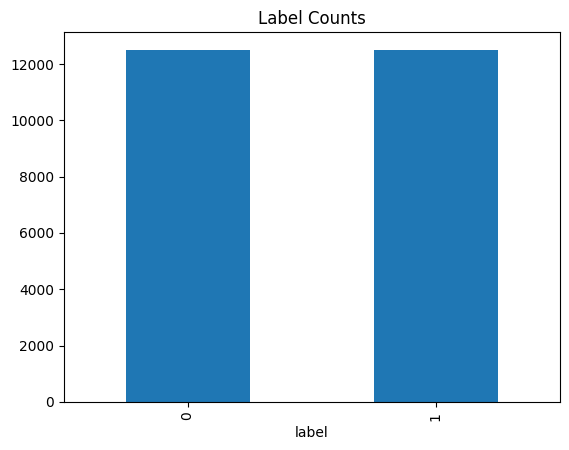

In [22]:
df_imdb['label'].value_counts().plot(kind='bar', title='Label Counts')

In [15]:
df_imdb['label'].value_counts()

label
0    12500
1    12500
Name: count, dtype: int64

##### It looks like training dataset is clas balanced plus 70% of the reviews have word count below 252. So token truncation at max_length of 256 will be more appropriate. If we choose less, we might risk not capturing enough information on review and our results may be flawed and not accurate. I have experimented with 64 and 128 max_len, results are not great

In [11]:
class Tokenize():
    def __init__(self, ckpt='gpt2', max_len=128):
        super().__init__()
        
        self.ds = "imdb"
        if(ckpt=='gpt2' or ckpt=='roberta-base'):
            self.ckpt = ckpt
        else:
            print("Checkpoint Model provided is invalid. Valid Values: gpt2, roberta-base. Setting it to default of gpt2")
            self.ckpt = 'gpt2'
        allowed_max_len = [64, 128, 256]
        if (max_len not in allowed_max_len):
            print("Tokenizer max length not valid. Allowed Values: 64, 128, 256. Defaulting to 128")
            self.max_len = 128
        else:
            self.max_len = max_len
        self.tokenizer = None
        
    def load_process_db(self):
        print("Loading dataset ..")
        dset = load_dataset(self.ds)
        dset = dset.rename_column('label', 'labels')
        ds_test = dset['test'].train_test_split(test_size=0.1, seed=42)
        ds_valid = ds_test['train'].train_test_split(test_size=0.1111, seed=42)
        ds_consol = datasets.DatasetDict({
            'train': dset['train'],
            'valid': ds_valid['test'],
            'test': ds_test['test']
            })
        self.ds = ds_consol
        
    def get_tokenizer(self):
        print("Loading Tokenizer....")
        tokenizer = AutoTokenizer.from_pretrained(self.ckpt)
        if self.ckpt=='gpt2':
            tokenizer.pad_token = tokenizer.eos_token
        self.tokenizer=tokenizer
        return tokenizer
            
    def tokenize_ds(self):
        self.load_process_db()
        tokenizer = self.get_tokenizer()
        print("Starting dataset tokenization.......Please wait ....")
        self.ds = self.ds.map(lambda x: tokenizer(x['text'], truncation=True, max_length=self.max_len, padding='max_length'), batched=True)
        return tokenizer

In [2]:
class Experiments():
    def __init__(self, tok_obj,ckpt='gpt2',lora=False, lora_rank=None, qlora=False, quant_bit=None, learning_rate=0.0002, num_epochs=1, verbose=False):
        super().__init__()
        
        self.tokenizer = tok_obj.tokenizer
        self.ds = tok_obj.ds
        if(ckpt=='gpt2' or ckpt=='roberta-base'):
            self.ckpt = ckpt
        else:
            print("Checkpoint Model provided is invalid. Valid Values: gpt2, roberta-base. Setting it to default of gpt2")
            self.ckpt = 'gpt2'
        if self.tokenizer.name_or_path != self.ckpt:
            print("Checkpoint provided is not compatible with tokenizer checkpoint. Defauting to tokenizer checkpoint")
            self.ckpt = self.tokenizer.name_or_path
            
        if(lora and qlora):
            print("Error: Both LoRA and QLoRA cannot be true. Defaulting to LoRA to True and QLoRA to False")
            self.lora = True
            self.qlora = False
        #//Check if lora and qlora are not boolean, default to lora and throw error message
        else:
            self.lora = lora
            self.qlora = qlora
        if(self.lora or self.qlora):
            allowed_ranks = [4,8,16,32]
            if (lora_rank not in allowed_ranks):
                print("Specified lora rank is not correct. Allowed values: 4,8,16,32. Setting to default of 16")
                self.lora_rank = 16
            else:
                self.lora_rank = lora_rank
            if(self.qlora):
                allowed_qbits = [4, 8]
                if (quant_bit not in allowed_qbits):
                    print("Quant bits supplied are incorrect. Allowed values: 4, 8. Defaulting to 8 bit")
                    self.quant_bit = 8
                else:
                    self.quant_bit = quant_bit
        self.lr = learning_rate
        self.num_epochs = num_epochs
        self.verbose = verbose
        
    
    def set_loraconfig(self):
        lora_config = LoraConfig(
            r=self.lora_rank, 
            lora_alpha=32,
            lora_dropout=0.05,
            task_type=TaskType.SEQ_CLS
        )
        return lora_config
    
    def get_quantconfig(self):
        if self.quant_bit==4:
            quantization_config = BitsAndBytesConfig(
                load_in_4bit=True,
                bnb_4bit_quant_type="nf4",
                bnb_4bit_use_double_quant=True,
                bnb_4bit_compute_dtype=torch.float16,
                )
        else:
            quantization_config = BitsAndBytesConfig(
                load_in_8bit=True,
                )
        return quantization_config
    
    def get_lora_model(self):
        print("LoRA is enabled. Loading LoRA Configuration and setting up PEFT Model")
        lora_config = self.set_loraconfig()
        base_model = AutoModelForSequenceClassification.from_pretrained(self.ckpt)
        if (self.ckpt=='gpt2'):
            base_model.config.pad_token_id = base_model.config.eos_token_id
        peft_model = get_peft_model(base_model, lora_config)
        print(f'PEFT mode is selected and we use LoRA method. Base Model is: {self.ckpt}')
        print(f'Total trainable parameters in selected peft model are {peft_model.print_trainable_parameters()}')
        return peft_model
    
    def get_qlora_model(self):
        print("QLoRA is enabled. Loading LoRA Configuration/Quantization config and setting up PEFT Model")
        lora_config = self.set_loraconfig()
        quant_config = self.get_quantconfig()
        model = AutoModelForSequenceClassification.from_pretrained(self.ckpt, quantization_config=quant_config)
        model.gradient_checkpointing_enable()
        model = prepare_model_for_kbit_training(model)
        if (self.ckpt=='gpt2'):
            model.config.pad_token_id = model.config.eos_token_id
            peft_model = get_peft_model(model, lora_config)
        elif (self.ckpt=='roberta-base'):
            model.add_adapter(lora_config, adapter_name="adapter_lora")
        print(f'PEFT mode is selected and we use QLoRA method. Base Model is: {self.ckpt}')
        print(f'Total trainable parameters in selected peft model can be seen in below output')
        if self.ckpt=='gpt2':
            print(summary(peft_model))
            return peft_model
        elif self.ckpt=='roberta-base':
            print(summary(model))
            return model
    
    def load_model(self):
        if(self.lora):
            model =  self.get_lora_model()
        elif(self.qlora):
            model = self.get_qlora_model()
        else:
            print(f'PEFT mode is not selected. We will do full fine-tuning. Base Model is: {self.ckpt}')
            model = AutoModelForSequenceClassification.from_pretrained(self.ckpt)
            if (self.ckpt=='gpt2'):
                model.config.pad_token_id = model.config.eos_token_id
            print("Model Summary can be seen in output below ....")
            print(summary(model))
        return model
            
    def get_training_args(self):
        print("Setting Training arguments ....")
        if self.qlora:
            fp16_enabled=True
        else:
            fp16_enabled=False
            
        if (self.lora or self.qlora):
            method_str="peft"
            if self.lora:
                train_str="LoRA"
            else:
                train_str="QLoRA"                
        else:
            method_str="non-peft"
            train_str ="full_tune"
        dtset = "imdb"
        now = datetime.now()
        current_time = now.strftime("%H%M%S%d%m")
        out_str = f'./{method_str}_{self.ckpt}_{train_str}_{dtset}_{current_time}'
        args = TrainingArguments(
            output_dir=out_str,
            evaluation_strategy='epoch',
            save_strategy='epoch',
            num_train_epochs=self.num_epochs,
            per_device_train_batch_size=16,
            per_device_eval_batch_size=16,
            learning_rate=self.lr,
            weight_decay=0.01,
            load_best_model_at_end=True,
            logging_steps=50,
            fp16=fp16_enabled
        )
        
        return args
    
    def compute_metrics(self, logits_and_labels):
        logits, labels = logits_and_labels
        preds = np.argmax(logits, axis=-1)
        accuracy = accuracy_score(labels, preds)
        f1 = f1_score(labels, preds)
        precision = precision_score(labels, preds)
        recall = recall_score(labels, preds)
        cm = confusion_matrix(labels, preds)
        specificity = cm[0,0]/(cm[0,0]+cm[0,1])
        precision_0 = cm[0,0]/(cm[0,0]+cm[1,0])
        return {'Accuracy': accuracy, 'F1_Score': f1, 'Precision': precision, 'Recall':recall, "Specificity":specificity,"precision_0_class": precision_0} #, 'Confusion Matrix': cm}

    def get_trainer_object(self, train_model, training_args):
        print("Setting Trainer object ....")
        
        trainer = Trainer(
            model=train_model,
            tokenizer=self.tokenizer,
            data_collator=DataCollatorWithPadding(tokenizer=self.tokenizer),
            args=training_args,
            train_dataset=self.ds['train'],
            eval_dataset=self.ds['valid'],
            compute_metrics=self.compute_metrics
        )
        return trainer
        
    
    def load_prep_model(self):
        print("Loading and Setting Training Model")
        loaded_model = self.load_model()
        return loaded_model

    
    def train_model(self):
        
        train_model = self.load_prep_model()
        training_args = self.get_training_args()
        trainer = self.get_trainer_object(train_model, training_args)
        if(self.verbose):
            print("Details of trainer object can be seen below")
            print(trainer.__dict__)
        print(f'***Training Starting now at {datetime.now()}******')
        trainer.train()
        print("Training Finished...Thanks for your patience")
        return trainer, trainer.model
        
        
    def evaluate_model(self, trainer, valid=True):
        if(not valid):
            trainer.eval_dataset = self.ds['test']
        stats = trainer.evaluate()
        return stats
            
    def save_model(self, trainer):
        save_path = f'{trainer.args.output_dir}_saved'
        trainer.save_model(save_path)
        return save_path
    
    def load_model_evaluate(self,save_path, valid=False):
        model_id = save_path
        if (self.qlora or self.lora):
            loaded_model = AutoPeftModelForSequenceClassification.from_pretrained(model_id, is_trainable=False)
        else:
            loaded_model = AutoModelForSequenceClassification.from_pretrained(model_id)
        print("Model Summary of loaded Model")
        print(summary(loaded_model))
        if valid:
            evaluation_ds = self.ds['valid']
        else:
            evaluation_ds = self.ds['test']
        if (self.ckpt == 'gpt2'):
            loaded_model.config.pad_token_id = loaded_model.config.eos_token_id
        
        trainer_eval = Trainer(
            model=loaded_model,
            tokenizer=self.tokenizer,
            train_dataset=self.ds['train'],
            eval_dataset=evaluation_ds,
            compute_metrics=self.compute_metrics
        )
        stats = trainer_eval.evaluate()
        return stats, trainer_eval

##### Let us get tokenizers for gpt2 and roberta

In [12]:
def tokenize_ds(ckpt='gpt2', max_len=256):
    tok_obj = Tokenize(ckpt=ckpt, max_len=max_len)
    print(f'Token object parameters: {tok_obj.__dict__}')
    tokenizer = tok_obj.tokenize_ds()
    print(f'Tokenizer details :{tokenizer}, Dataset Details: {tok_obj.ds}')
    return tokenizer, tok_obj

In [30]:
tokenizer_gpt2_256, tok_obj_gpt2_256 = tokenize_ds(ckpt='gpt2')

Token object parameters: {'ds': 'imdb', 'ckpt': 'gpt2', 'max_len': 256, 'tokenizer': None}
Loading dataset ..
Loading Tokenizer....


tokenizer_config.json: 100%|██████████| 26.0/26.0 [00:00<00:00, 41.4kB/s]
config.json: 100%|██████████| 665/665 [00:00<00:00, 3.04MB/s]
vocab.json: 100%|██████████| 1.04M/1.04M [00:00<00:00, 15.5MB/s]
merges.txt: 100%|██████████| 456k/456k [00:00<00:00, 12.0MB/s]
tokenizer.json: 100%|██████████| 1.36M/1.36M [00:00<00:00, 16.7MB/s]


Starting dataset tokenization.......Please wait ....


Map: 100%|██████████| 2500/2500 [00:02<00:00, 846.25 examples/s]

Tokenizer details :GPT2TokenizerFast(name_or_path='gpt2', vocab_size=50257, model_max_length=1024, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<|endoftext|>', 'eos_token': '<|endoftext|>', 'unk_token': '<|endoftext|>', 'pad_token': '<|endoftext|>'}, clean_up_tokenization_spaces=True),  added_tokens_decoder={
	50256: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
}, Dataset Details: DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 25000
    })
    valid: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 2500
    })
    test: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 2500
    })
})


In [31]:
tokenizer_ro_base_256, tok_obj_ro_base_256 = tokenize_ds(ckpt='roberta-base')

Token object parameters: {'ds': 'imdb', 'ckpt': 'roberta-base', 'max_len': 256, 'tokenizer': None}
Loading dataset ..
Loading Tokenizer....


tokenizer_config.json: 100%|██████████| 25.0/25.0 [00:00<00:00, 87.9kB/s]
config.json: 100%|██████████| 481/481 [00:00<00:00, 2.16MB/s]
vocab.json: 100%|██████████| 899k/899k [00:00<00:00, 10.0MB/s]
merges.txt: 100%|██████████| 456k/456k [00:00<00:00, 18.1MB/s]
tokenizer.json: 100%|██████████| 1.36M/1.36M [00:00<00:00, 12.8MB/s]


Starting dataset tokenization.......Please wait ....


Map: 100%|██████████| 2500/2500 [00:03<00:00, 801.78 examples/s]

Tokenizer details :RobertaTokenizerFast(name_or_path='roberta-base', vocab_size=50265, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'sep_token': '</s>', 'pad_token': '<pad>', 'cls_token': '<s>', 'mask_token': '<mask>'}, clean_up_tokenization_spaces=True),  added_tokens_decoder={
	0: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	1: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	2: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	3: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	50264: AddedToken("<mask>", rstrip=False, lstrip=True, single_word=False, normalized=False, special=True),
}, Dataset Details: DatasetDict({
    train: Dataset({
        features: ['text', 'lab

In [36]:
import copy

In [32]:
def eval_pretrain(tok_obj, ckpt):
    eval_exp = Experiments(tok_obj,ckpt=ckpt)
    print(f'Evaluation Experiment Object Details: {eval_exp.__dict__}')
    stats_test, trainer_eval = eval_exp.load_model_evaluate(save_path=ckpt, valid=False)
    print(f'Test Evaluation statistics for model: {ckpt} , Max_Len set to {tok_obj.max_len}, \n {stats_test}')
    stats_valid, trainer_eval = eval_exp.load_model_evaluate(save_path=ckpt, valid=True)
    print(f'Validation Evaluation statistics for model: {ckpt} , Max_Len set to {tok_obj.max_len}, \n {stats_valid}')
    return eval_exp, stats_valid, stats_test

In [44]:
eval_exp_gpt2_256, stats_valid_gpt2_256, stats_test_gpt2_256 = eval_pretrain(tok_obj=tok_obj_gpt2_256, ckpt='gpt2')

Evaluation Experiment Object Details: {'tokenizer': GPT2TokenizerFast(name_or_path='gpt2', vocab_size=50257, model_max_length=1024, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<|endoftext|>', 'eos_token': '<|endoftext|>', 'unk_token': '<|endoftext|>', 'pad_token': '<|endoftext|>'}, clean_up_tokenization_spaces=True),  added_tokens_decoder={
	50256: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
}, 'ds': DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 25000
    })
    valid: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 2500
    })
    test: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 2500
    })
}), 'ckpt': 'gpt2', 'lora': False, 'qlora': False, 'lr': 0.0002, 'num_epochs': 1, 'verbose': False}


Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model Summary of loaded Model
Layer (type:depth-idx)                             Param #
GPT2ForSequenceClassification                      --
├─GPT2Model: 1-1                                   --
│    └─Embedding: 2-1                              38,597,376
│    └─Embedding: 2-2                              786,432
│    └─Dropout: 2-3                                --
│    └─ModuleList: 2-4                             --
│    │    └─GPT2Block: 3-1                         7,087,872
│    │    └─GPT2Block: 3-2                         7,087,872
│    │    └─GPT2Block: 3-3                         7,087,872
│    │    └─GPT2Block: 3-4                         7,087,872
│    │    └─GPT2Block: 3-5                         7,087,872
│    │    └─GPT2Block: 3-6                         7,087,872
│    │    └─GPT2Block: 3-7                         7,087,872
│    │    └─GPT2Block: 3-8                         7,087,872
│    │    └─GPT2Block: 3-9                         7,087,872
│    │    └─GPT2Block: 3-

Test Evaluation statistics for model: gpt2 , Max_Len set to 256, 
 {'eval_loss': 0.8255544900894165, 'eval_Accuracy': 0.506, 'eval_F1_Score': 0.1057204923968139, 'eval_Precision': 0.5887096774193549, 'eval_Recall': 0.05807478122513922, 'eval_Specificity': 0.9589702333065165, 'eval_precision_0_class': 0.5016835016835017, 'eval_runtime': 41.8611, 'eval_samples_per_second': 59.721, 'eval_steps_per_second': 7.477}


Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model Summary of loaded Model
Layer (type:depth-idx)                             Param #
GPT2ForSequenceClassification                      --
├─GPT2Model: 1-1                                   --
│    └─Embedding: 2-1                              38,597,376
│    └─Embedding: 2-2                              786,432
│    └─Dropout: 2-3                                --
│    └─ModuleList: 2-4                             --
│    │    └─GPT2Block: 3-1                         7,087,872
│    │    └─GPT2Block: 3-2                         7,087,872
│    │    └─GPT2Block: 3-3                         7,087,872
│    │    └─GPT2Block: 3-4                         7,087,872
│    │    └─GPT2Block: 3-5                         7,087,872
│    │    └─GPT2Block: 3-6                         7,087,872
│    │    └─GPT2Block: 3-7                         7,087,872
│    │    └─GPT2Block: 3-8                         7,087,872
│    │    └─GPT2Block: 3-9                         7,087,872
│    │    └─GPT2Block: 3-

Validation Evaluation statistics for model: gpt2 , Max_Len set to 256, 
 {'eval_loss': 0.8136314749717712, 'eval_Accuracy': 0.5004, 'eval_F1_Score': 0.12350877192982457, 'eval_Precision': 0.5641025641025641, 'eval_Recall': 0.06934594168636722, 'eval_Specificity': 0.9447603574329814, 'eval_precision_0_class': 0.496160409556314, 'eval_runtime': 42.3292, 'eval_samples_per_second': 59.061, 'eval_steps_per_second': 7.394}


##### GPT model is giving results that are at the best random guesses. So will need to fine tune GPT2 and we will also use roberta-base in LoRA variants.

In [48]:
def run_exp(tok_obj, ckpt, lora=False, lora_rank=None, qlora=False, quant_bit=None, learning_rate=0.0002, num_epochs=1, verbose=False):
    exp_obj = Experiments(tok_obj, ckpt=ckpt, lora=lora, lora_rank=lora_rank, qlora=qlora, quant_bit=quant_bit, learning_rate=learning_rate, num_epochs=num_epochs)
    print(f'Experiment Object details : {exp_obj.__dict__}')
    trainer, model = exp_obj.train_model()
    stats_valid = exp_obj.evaluate_model(trainer, valid=True)
    stats_test = exp_obj.evaluate_model(trainer, valid=False)
    print(f'Validation Evaluation Statistics {stats_valid}')
    print(f'Test Evaluation Statistics {stats_test}')
    save_path = exp_obj.save_model(trainer)
    print(f'Model Save Path is {save_path}')
    return exp_obj, trainer, stats_valid, stats_test, save_path

In [49]:
exp_obj_gpt2_256, trainer_gpt2_256, stats_valid_gpt2_256, stats_test_gpt2_256, save_path_gpt2_256 = run_exp(tok_obj_gpt2_256, ckpt='gpt2')

Experiment Object details : {'tokenizer': GPT2TokenizerFast(name_or_path='gpt2', vocab_size=50257, model_max_length=1024, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<|endoftext|>', 'eos_token': '<|endoftext|>', 'unk_token': '<|endoftext|>', 'pad_token': '<|endoftext|>'}, clean_up_tokenization_spaces=True),  added_tokens_decoder={
	50256: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
}, 'ds': DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 25000
    })
    valid: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 2500
    })
    test: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 2500
    })
}), 'ckpt': 'gpt2', 'lora': False, 'qlora': False, 'lr': 0.0002, 'num_epochs': 1, 'verbose': False}
Loading and Setting Tr

Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model Summary can be seen in output below ....
Layer (type:depth-idx)                             Param #
GPT2ForSequenceClassification                      --
├─GPT2Model: 1-1                                   --
│    └─Embedding: 2-1                              38,597,376
│    └─Embedding: 2-2                              786,432
│    └─Dropout: 2-3                                --
│    └─ModuleList: 2-4                             --
│    │    └─GPT2Block: 3-1                         7,087,872
│    │    └─GPT2Block: 3-2                         7,087,872
│    │    └─GPT2Block: 3-3                         7,087,872
│    │    └─GPT2Block: 3-4                         7,087,872
│    │    └─GPT2Block: 3-5                         7,087,872
│    │    └─GPT2Block: 3-6                         7,087,872
│    │    └─GPT2Block: 3-7                         7,087,872
│    │    └─GPT2Block: 3-8                         7,087,872
│    │    └─GPT2Block: 3-9                         7,087,872
│    │  

Epoch,Training Loss,Validation Loss,Accuracy,F1 Score,Precision,Recall,Specificity,Precision 0 Class
1,0.248300,0.243582,0.904400,0.903900,0.922824,0.885737,0.923639,0.886895


Training Finished...Thanks for your patience


Validation Evaluation Statistics {'eval_loss': 0.2435815930366516, 'eval_Accuracy': 0.9044, 'eval_F1_Score': 0.9039002814636108, 'eval_Precision': 0.922824302134647, 'eval_Recall': 0.8857368006304176, 'eval_Specificity': 0.9236393176279447, 'eval_precision_0_class': 0.8868954758190327, 'eval_runtime': 41.0597, 'eval_samples_per_second': 60.887, 'eval_steps_per_second': 3.824, 'epoch': 1.0}
Test Evaluation Statistics {'eval_loss': 0.2482089102268219, 'eval_Accuracy': 0.9028, 'eval_F1_Score': 0.9007758268681094, 'eval_Precision': 0.9253355704697986, 'eval_Recall': 0.8774860779634049, 'eval_Specificity': 0.9283990345937249, 'eval_precision_0_class': 0.882262996941896, 'eval_runtime': 40.8995, 'eval_samples_per_second': 61.125, 'eval_steps_per_second': 3.839, 'epoch': 1.0}
Model Save Path is ./non-peft_gpt2_full_tune_imdb_0519362402_saved


In [52]:
pd.DataFrame(stats_test_gpt2_256, index=range(0,1))

,eval_loss,eval_Accuracy,eval_F1_Score,eval_Precision,eval_Recall,eval_Specificity,eval_precision_0_class,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch
0,0.248209,0.9028,0.900776,0.925336,0.877486,0.928399,0.882263,40.8995,61.125,3.839,1.0


In [53]:
stats_test_gpt2_256['run'] = "GPT2 FFT"

In [54]:
df_stats_test = pd.DataFrame(stats_test_gpt2_256, index=range(0,1))
df_stats_test

,eval_loss,eval_Accuracy,eval_F1_Score,eval_Precision,eval_Recall,eval_Specificity,eval_precision_0_class,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch,run
0,0.248209,0.9028,0.900776,0.925336,0.877486,0.928399,0.882263,40.8995,61.125,3.839,1.0,GPT2 FFT


In [61]:
df_stats_test['model_path'] = save_path_gpt2_256
df_stats_test

,eval_loss,eval_Accuracy,eval_F1_Score,eval_Precision,eval_Recall,eval_Specificity,eval_precision_0_class,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch,run,model_path
0,0.248209,0.9028,0.900776,0.925336,0.877486,0.928399,0.882263,40.8995,61.125,3.839,1.0,GPT2 FFT,./non-peft_gpt2_full_tune_imdb_0519362402_saved


In [62]:
df_stats_test.to_csv("Test_Stats.csv")

In [100]:
stats_valid_gpt2_256['run'] = "GPT2 FFT"
stats_valid_gpt2_256['model_path'] = save_path_gpt2_256

In [101]:
df_stats_valid = pd.DataFrame(stats_valid_gpt2_256, index=range(0,1))
df_stats_valid

,eval_loss,eval_Accuracy,eval_F1_Score,eval_Precision,eval_Recall,eval_Specificity,eval_precision_0_class,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch,run,model_path,file_size
0,0.243582,0.9044,0.9039,0.922824,0.885737,0.923639,0.886895,41.0597,60.887,3.824,1.0,GPT2 FFT,./non-peft_gpt2_full_tune_imdb_0519362402_saved,475M


In [103]:
df_stats_valid.drop(columns=['file_size'], inplace=True)

In [104]:
df_stats_valid

,eval_loss,eval_Accuracy,eval_F1_Score,eval_Precision,eval_Recall,eval_Specificity,eval_precision_0_class,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch,run,model_path
0,0.243582,0.9044,0.9039,0.922824,0.885737,0.923639,0.886895,41.0597,60.887,3.824,1.0,GPT2 FFT,./non-peft_gpt2_full_tune_imdb_0519362402_saved


In [105]:
df_stats_valid.to_csv("Valid_Stats.csv")

## Performing Parameter-Efficient Fine-Tuning

TODO: In the cells below, create a PEFT model from your loaded model, run a training loop, and save the PEFT model weights.

In [120]:
def update_stats(run_str, save_path, test_dict, df_stats_test):
    test_dict['run'] = run_str
    test_dict['model_path'] = save_path
    df_stats_test_new = pd.DataFrame(test_dict, index=range(0,1))
    df_stats_test = pd.concat([df_stats_test, df_stats_test_new], axis=0)
    df_stats_test.to_csv("Valid_Stats.csv")
    return df_stats_test


In [59]:
l16_exp_obj_gpt2_256, l16_trainer_gpt2_256, l16_stats_valid_gpt2_256, l16_stats_test_gpt2_256, l16_save_path_gpt2_256 = run_exp(tok_obj_gpt2_256,
                                                                                                                                ckpt='gpt2', lora=True, lora_rank=16,
                                                                                                                                qlora=False, quant_bit=None, learning_rate=0.0008, 
                                                                                                                                num_epochs=2, verbose=False)

Experiment Object details : {'tokenizer': GPT2TokenizerFast(name_or_path='gpt2', vocab_size=50257, model_max_length=1024, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<|endoftext|>', 'eos_token': '<|endoftext|>', 'unk_token': '<|endoftext|>', 'pad_token': '<|endoftext|>'}, clean_up_tokenization_spaces=True),  added_tokens_decoder={
	50256: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
}, 'ds': DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 25000
    })
    valid: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 2500
    })
    test: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 2500
    })
}), 'ckpt': 'gpt2', 'lora': True, 'qlora': False, 'lora_rank': 16, 'lr': 0.0008, 'num_epochs': 2, 'verbose': False}
Loadin

Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/opt/conda/lib/python3.10/site-packages/peft/tuners/lora.py:475: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


PEFT mode is selected and we use LoRA method. Base Model is: gpt2
trainable params: 592,896 || all params: 125,032,704 || trainable%: 0.47419273600609324
Total trainable parameters in selected peft model are None
Setting Training arguments ....
Setting Trainer object ....
***Training Starting now at 2024-02-24 06:11:23.690636******


Epoch,Training Loss,Validation Loss,Accuracy,F1 Score,Precision,Recall,Specificity,Precision 0 Class
1,0.264200,0.231428,0.911200,0.910121,0.935887,0.885737,0.937449,0.888376
2,0.195500,0.212281,0.920800,0.921986,0.921986,0.921986,0.919578,0.919578


Training Finished...Thanks for your patience


Validation Evaluation Statistics {'eval_loss': 0.21228091418743134, 'eval_Accuracy': 0.9208, 'eval_F1_Score': 0.9219858156028369, 'eval_Precision': 0.9219858156028369, 'eval_Recall': 0.9219858156028369, 'eval_Specificity': 0.9195775792038993, 'eval_precision_0_class': 0.9195775792038993, 'eval_runtime': 42.3672, 'eval_samples_per_second': 59.008, 'eval_steps_per_second': 3.706, 'epoch': 2.0}
Test Evaluation Statistics {'eval_loss': 0.21193070709705353, 'eval_Accuracy': 0.9144, 'eval_F1_Score': 0.9144, 'eval_Precision': 0.919549477071601, 'eval_Recall': 0.9093078758949881, 'eval_Specificity': 0.919549477071601, 'eval_precision_0_class': 0.9093078758949881, 'eval_runtime': 42.2924, 'eval_samples_per_second': 59.112, 'eval_steps_per_second': 3.712, 'epoch': 2.0}
Model Save Path is ./peft_gpt2_LoRA_imdb_0611232402_saved


In [60]:
!ls -ltrh {l16_save_path_gpt2_256}

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


total 5.5M
-rw-r--r-- 1 student student   88 Feb 24 06:46 README.md
-rw-r--r-- 1 student student 2.3M Feb 24 06:46 adapter_model.safetensors
-rw-r--r-- 1 student student  410 Feb 24 06:46 adapter_config.json
-rw-r--r-- 1 student student  476 Feb 24 06:46 tokenizer_config.json
-rw-r--r-- 1 student student  131 Feb 24 06:46 special_tokens_map.json
-rw-r--r-- 1 student student 780K Feb 24 06:46 vocab.json
-rw-r--r-- 1 student student 446K Feb 24 06:46 merges.txt
-rw-r--r-- 1 student student 2.1M Feb 24 06:46 tokenizer.json
-rw-r--r-- 1 student student 4.5K Feb 24 06:46 training_args.bin


In [64]:
run_str= "LoRA_R16_GPT2"
save_path = l16_save_path_gpt2_256
test_dict = l16_stats_test_gpt2_256
df_stats_test = update_stats(run_str, save_path, test_dict, df_stats_test)
df_stats_test

,eval_loss,eval_Accuracy,eval_F1_Score,eval_Precision,eval_Recall,eval_Specificity,eval_precision_0_class,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch,run,model_path
0,0.248209,0.9028,0.900776,0.925336,0.877486,0.928399,0.882263,40.8995,61.125,3.839,1.0,GPT2 FFT,./non-peft_gpt2_full_tune_imdb_0519362402_saved
0,0.211931,0.9144,0.914400,0.919549,0.909308,0.919549,0.909308,42.2924,59.112,3.712,2.0,LoRA_R16_GPT2,./peft_gpt2_LoRA_imdb_0611232402_saved


In [106]:
run_str= "LoRA_R16_GPT2"
save_path = l16_save_path_gpt2_256
valid_dict = l16_stats_valid_gpt2_256
df_stats_valid = update_stats(run_str, save_path, valid_dict, df_stats_valid)
df_stats_valid

,eval_loss,eval_Accuracy,eval_F1_Score,eval_Precision,eval_Recall,eval_Specificity,eval_precision_0_class,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch,run,model_path
0,0.243582,0.9044,0.903900,0.922824,0.885737,0.923639,0.886895,41.0597,60.887,3.824,1.0,GPT2 FFT,./non-peft_gpt2_full_tune_imdb_0519362402_saved
0,0.212281,0.9208,0.921986,0.921986,0.921986,0.919578,0.919578,42.3672,59.008,3.706,2.0,LoRA_R16_GPT2,./peft_gpt2_LoRA_imdb_0611232402_saved


In [65]:
l8_exp_obj_gpt2_256, l8_trainer_gpt2_256, l8_stats_valid_gpt2_256, l8_stats_test_gpt2_256, l8_save_path_gpt2_256 = run_exp(tok_obj_gpt2_256,
                                                                                                                           ckpt='gpt2', lora=True, lora_rank=8,
                                                                                                                           qlora=False, quant_bit=None, learning_rate=0.0008, 
                                                                                                                           num_epochs=2, verbose=False)


Experiment Object details : {'tokenizer': GPT2TokenizerFast(name_or_path='gpt2', vocab_size=50257, model_max_length=1024, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<|endoftext|>', 'eos_token': '<|endoftext|>', 'unk_token': '<|endoftext|>', 'pad_token': '<|endoftext|>'}, clean_up_tokenization_spaces=True),  added_tokens_decoder={
	50256: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
}, 'ds': DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 25000
    })
    valid: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 2500
    })
    test: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 2500
    })
}), 'ckpt': 'gpt2', 'lora': True, 'qlora': False, 'lora_rank': 8, 'lr': 0.0008, 'num_epochs': 2, 'verbose': False}
Loading

Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/opt/conda/lib/python3.10/site-packages/peft/tuners/lora.py:475: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


PEFT mode is selected and we use LoRA method. Base Model is: gpt2
trainable params: 297,984 || all params: 124,737,792 || trainable%: 0.23888830740245906
Total trainable parameters in selected peft model are None
Setting Training arguments ....
Setting Trainer object ....
***Training Starting now at 2024-02-24 06:48:25.885073******


Epoch,Training Loss,Validation Loss,Accuracy,F1 Score,Precision,Recall,Specificity,Precision 0 Class
1,0.278400,0.231302,0.910000,0.909457,0.929276,0.890465,0.930138,0.891745
2,0.190900,0.216569,0.920800,0.921863,0.923320,0.920410,0.921202,0.918219


Training Finished...Thanks for your patience


Validation Evaluation Statistics {'eval_loss': 0.21656890213489532, 'eval_Accuracy': 0.9208, 'eval_F1_Score': 0.9218626677190213, 'eval_Precision': 0.9233201581027668, 'eval_Recall': 0.9204097714736013, 'eval_Specificity': 0.9212022745735174, 'eval_precision_0_class': 0.9182186234817814, 'eval_runtime': 42.3549, 'eval_samples_per_second': 59.025, 'eval_steps_per_second': 3.707, 'epoch': 2.0}
Test Evaluation Statistics {'eval_loss': 0.20764872431755066, 'eval_Accuracy': 0.9232, 'eval_F1_Score': 0.9228295819935691, 'eval_Precision': 0.9325751421608448, 'eval_Recall': 0.9132856006364359, 'eval_Specificity': 0.9332260659694288, 'eval_precision_0_class': 0.9141055949566588, 'eval_runtime': 42.289, 'eval_samples_per_second': 59.117, 'eval_steps_per_second': 3.713, 'epoch': 2.0}
Model Save Path is ./peft_gpt2_LoRA_imdb_0648252402_saved


In [66]:
!ls -l {l8_save_path_gpt2_256}
run_str= "LoRA_R8_GPT2"
save_path = l8_save_path_gpt2_256
test_dict = l8_stats_test_gpt2_256
df_stats_test = update_stats(run_str, save_path, test_dict, df_stats_test)
df_stats_test

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


total 4476
-rw-r--r-- 1 student student      88 Feb 24 07:23 README.md
-rw-r--r-- 1 student student     409 Feb 24 07:23 adapter_config.json
-rw-r--r-- 1 student student 1188920 Feb 24 07:23 adapter_model.safetensors
-rw-r--r-- 1 student student  456318 Feb 24 07:23 merges.txt
-rw-r--r-- 1 student student     131 Feb 24 07:23 special_tokens_map.json
-rw-r--r-- 1 student student 2107929 Feb 24 07:23 tokenizer.json
-rw-r--r-- 1 student student     476 Feb 24 07:23 tokenizer_config.json
-rw-r--r-- 1 student student    4539 Feb 24 07:23 training_args.bin
-rw-r--r-- 1 student student  798156 Feb 24 07:23 vocab.json


,eval_loss,eval_Accuracy,eval_F1_Score,eval_Precision,eval_Recall,eval_Specificity,eval_precision_0_class,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch,run,model_path
0,0.248209,0.9028,0.900776,0.925336,0.877486,0.928399,0.882263,40.8995,61.125,3.839,1.0,GPT2 FFT,./non-peft_gpt2_full_tune_imdb_0519362402_saved
0,0.211931,0.9144,0.914400,0.919549,0.909308,0.919549,0.909308,42.2924,59.112,3.712,2.0,LoRA_R16_GPT2,./peft_gpt2_LoRA_imdb_0611232402_saved
0,0.207649,0.9232,0.922830,0.932575,0.913286,0.933226,0.914106,42.2890,59.117,3.713,2.0,LoRA_R8_GPT2,./peft_gpt2_LoRA_imdb_0648252402_saved


In [107]:
run_str= "LoRA_R8_GPT2"
save_path = l8_save_path_gpt2_256
valid_dict = l8_stats_valid_gpt2_256
df_stats_valid = update_stats(run_str, save_path, valid_dict, df_stats_valid)
df_stats_valid

,eval_loss,eval_Accuracy,eval_F1_Score,eval_Precision,eval_Recall,eval_Specificity,eval_precision_0_class,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch,run,model_path
0,0.243582,0.9044,0.903900,0.922824,0.885737,0.923639,0.886895,41.0597,60.887,3.824,1.0,GPT2 FFT,./non-peft_gpt2_full_tune_imdb_0519362402_saved
0,0.212281,0.9208,0.921986,0.921986,0.921986,0.919578,0.919578,42.3672,59.008,3.706,2.0,LoRA_R16_GPT2,./peft_gpt2_LoRA_imdb_0611232402_saved
0,0.216569,0.9208,0.921863,0.923320,0.920410,0.921202,0.918219,42.3549,59.025,3.707,2.0,LoRA_R8_GPT2,./peft_gpt2_LoRA_imdb_0648252402_saved


In [67]:
l8q8_exp_obj_gpt2_256, l8q8_trainer_gpt2_256, l8q8_stats_valid_gpt2_256, l8q8_stats_test_gpt2_256, l8q8_save_path_gpt2_256 = run_exp(tok_obj_gpt2_256,
                                                                                                                                     ckpt='gpt2', lora=False, lora_rank=8,
                                                                                                                                     qlora=True, quant_bit=8, learning_rate=0.0008, 
                                                                                                                                     num_epochs=2, verbose=False)


`low_cpu_mem_usage` was None, now set to True since model is quantized.


Experiment Object details : {'tokenizer': GPT2TokenizerFast(name_or_path='gpt2', vocab_size=50257, model_max_length=1024, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<|endoftext|>', 'eos_token': '<|endoftext|>', 'unk_token': '<|endoftext|>', 'pad_token': '<|endoftext|>'}, clean_up_tokenization_spaces=True),  added_tokens_decoder={
	50256: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
}, 'ds': DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 25000
    })
    valid: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 2500
    })
    test: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 2500
    })
}), 'ckpt': 'gpt2', 'lora': False, 'qlora': True, 'lora_rank': 8, 'quant_bit': 8, 'lr': 0.0008, 'num_epochs': 2, 'verbose'

Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


PEFT mode is selected and we use QLoRA method. Base Model is: gpt2
Total trainable parameters in selected peft model can be seen in below output
Layer (type:depth-idx)                                       Param #
PeftModelForSequenceClassification                           --
├─LoraModel: 1-1                                             --
│    └─GPT2ForSequenceClassification: 2-1                    --
│    │    └─GPT2Model: 3-1                                   124,734,720
│    │    └─ModulesToSaveWrapper: 3-2                        3,072
Total params: 124,737,792
Trainable params: 297,984
Non-trainable params: 124,439,808
Setting Training arguments ....
Setting Trainer object ....
***Training Starting now at 2024-02-24 07:26:38.254724******


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...
/home/student/.local/lib/python3.10/site-packages/bitsandbytes/autograd/_functions.py:322: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


...

/home/student/.local/lib/python3.10/site-packages/bitsandbytes/autograd/_functions.py:322: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


Training Finished...Thanks for your patience


/home/student/.local/lib/python3.10/site-packages/bitsandbytes/autograd/_functions.py:322: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


/home/student/.local/lib/python3.10/site-packages/bitsandbytes/autograd/_functions.py:322: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


Validation Evaluation Statistics {'eval_loss': 0.21904981136322021, 'eval_Accuracy': 0.9228, 'eval_F1_Score': 0.92410538733779, 'eval_Precision': 0.9222919937205651, 'eval_Recall': 0.9259259259259259, 'eval_Specificity': 0.9195775792038993, 'eval_precision_0_class': 0.9233278955954323, 'eval_runtime': 34.2077, 'eval_samples_per_second': 73.083, 'eval_steps_per_second': 4.59, 'epoch': 2.0}
Test Evaluation Statistics {'eval_loss': 0.20448751747608185, 'eval_Accuracy': 0.9216, 'eval_F1_Score': 0.9219123505976096, 'eval_Precision': 0.9233838786911412, 'eval_Recall': 0.9204455051710422, 'eval_Specificity': 0.9227674979887369, 'eval_precision_0_class': 0.9198075380914194, 'eval_runtime': 34.2503, 'eval_samples_per_second': 72.992, 'eval_steps_per_second': 4.584, 'epoch': 2.0}
Model Save Path is ./peft_gpt2_QLoRA_imdb_0726382402_saved


In [68]:
!ls -l {l8q8_save_path_gpt2_256}
run_str= "QLoRA_R8_Q8_GPT2"
save_path = l8q8_save_path_gpt2_256
test_dict = l8q8_stats_test_gpt2_256
df_stats_test = update_stats(run_str, save_path, test_dict, df_stats_test)
df_stats_test

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


total 4476
-rw-r--r-- 1 student student     509 Feb 24 08:08 README.md
-rw-r--r-- 1 student student     410 Feb 24 08:08 adapter_config.json
-rw-r--r-- 1 student student 1188920 Feb 24 08:08 adapter_model.safetensors
-rw-r--r-- 1 student student  456318 Feb 24 08:08 merges.txt
-rw-r--r-- 1 student student     131 Feb 24 08:08 special_tokens_map.json
-rw-r--r-- 1 student student 2107929 Feb 24 08:08 tokenizer.json
-rw-r--r-- 1 student student     476 Feb 24 08:08 tokenizer_config.json
-rw-r--r-- 1 student student    4539 Feb 24 08:08 training_args.bin
-rw-r--r-- 1 student student  798156 Feb 24 08:08 vocab.json


,eval_loss,eval_Accuracy,eval_F1_Score,eval_Precision,eval_Recall,eval_Specificity,eval_precision_0_class,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch,run,model_path
0,0.248209,0.9028,0.900776,0.925336,0.877486,0.928399,0.882263,40.8995,61.125,3.839,1.0,GPT2 FFT,./non-peft_gpt2_full_tune_imdb_0519362402_saved
0,0.211931,0.9144,0.914400,0.919549,0.909308,0.919549,0.909308,42.2924,59.112,3.712,2.0,LoRA_R16_GPT2,./peft_gpt2_LoRA_imdb_0611232402_saved
0,0.207649,0.9232,0.922830,0.932575,0.913286,0.933226,0.914106,42.2890,59.117,3.713,2.0,LoRA_R8_GPT2,./peft_gpt2_LoRA_imdb_0648252402_saved
0,0.204488,0.9216,0.921912,0.923384,0.920446,0.922767,0.919808,34.2503,72.992,4.584,2.0,QLoRA_R8_Q8_GPT2,./peft_gpt2_QLoRA_imdb_0726382402_saved


In [108]:
run_str= "QLoRA_R8_Q8_GPT2"
save_path = l8q8_save_path_gpt2_256
valid_dict = l8q8_stats_valid_gpt2_256
df_stats_valid = update_stats(run_str, save_path, valid_dict, df_stats_valid)
df_stats_valid

,eval_loss,eval_Accuracy,eval_F1_Score,eval_Precision,eval_Recall,eval_Specificity,eval_precision_0_class,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch,run,model_path
0,0.243582,0.9044,0.903900,0.922824,0.885737,0.923639,0.886895,41.0597,60.887,3.824,1.0,GPT2 FFT,./non-peft_gpt2_full_tune_imdb_0519362402_saved
0,0.212281,0.9208,0.921986,0.921986,0.921986,0.919578,0.919578,42.3672,59.008,3.706,2.0,LoRA_R16_GPT2,./peft_gpt2_LoRA_imdb_0611232402_saved
0,0.216569,0.9208,0.921863,0.923320,0.920410,0.921202,0.918219,42.3549,59.025,3.707,2.0,LoRA_R8_GPT2,./peft_gpt2_LoRA_imdb_0648252402_saved
0,0.219050,0.9228,0.924105,0.922292,0.925926,0.919578,0.923328,34.2077,73.083,4.590,2.0,QLoRA_R8_Q8_GPT2,./peft_gpt2_QLoRA_imdb_0726382402_saved


In [69]:
l8q4_exp_obj_gpt2_256, l8q4_trainer_gpt2_256, l8q4_stats_valid_gpt2_256, l8q4_stats_test_gpt2_256, l8q4_save_path_gpt2_256 = run_exp(tok_obj_gpt2_256,
                                                                                                                                     ckpt='gpt2', lora=False, lora_rank=8,
                                                                                                                                     qlora=True, quant_bit=4, learning_rate=0.0008, 
                                                                                                                                     num_epochs=2, verbose=False)


`low_cpu_mem_usage` was None, now set to True since model is quantized.


Experiment Object details : {'tokenizer': GPT2TokenizerFast(name_or_path='gpt2', vocab_size=50257, model_max_length=1024, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<|endoftext|>', 'eos_token': '<|endoftext|>', 'unk_token': '<|endoftext|>', 'pad_token': '<|endoftext|>'}, clean_up_tokenization_spaces=True),  added_tokens_decoder={
	50256: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
}, 'ds': DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 25000
    })
    valid: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 2500
    })
    test: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 2500
    })
}), 'ckpt': 'gpt2', 'lora': False, 'qlora': True, 'lora_rank': 8, 'quant_bit': 4, 'lr': 0.0008, 'num_epochs': 2, 'verbose'

Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


PEFT mode is selected and we use QLoRA method. Base Model is: gpt2
Total trainable parameters in selected peft model can be seen in below output
Layer (type:depth-idx)                                       Param #
PeftModelForSequenceClassification                           --
├─LoraModel: 1-1                                             --
│    └─GPT2ForSequenceClassification: 2-1                    --
│    │    └─GPT2Model: 3-1                                   82,267,392
│    │    └─ModulesToSaveWrapper: 3-2                        3,072
Total params: 82,270,464
Trainable params: 297,984
Non-trainable params: 81,972,480
Setting Training arguments ....
Setting Trainer object ....
***Training Starting now at 2024-02-24 08:10:13.456805******


Epoch,Training Loss,Validation Loss,Accuracy,F1 Score,Precision,Recall,Specificity,Precision 0 Class
1,0.284300,0.224625,0.910000,0.913094,0.895455,0.931442,0.887896,0.926271
2,0.203000,0.218357,0.923600,0.924951,0.922414,0.927502,0.919578,0.924837


Training Finished...Thanks for your patience


Validation Evaluation Statistics {'eval_loss': 0.21835727989673615, 'eval_Accuracy': 0.9236, 'eval_F1_Score': 0.924950884086444, 'eval_Precision': 0.9224137931034483, 'eval_Recall': 0.9275019700551616, 'eval_Specificity': 0.9195775792038993, 'eval_precision_0_class': 0.9248366013071896, 'eval_runtime': 24.1471, 'eval_samples_per_second': 103.532, 'eval_steps_per_second': 6.502, 'epoch': 2.0}
Test Evaluation Statistics {'eval_loss': 0.21456606686115265, 'eval_Accuracy': 0.922, 'eval_F1_Score': 0.9226497421658072, 'eval_Precision': 0.9200949367088608, 'eval_Recall': 0.9252187748607796, 'eval_Specificity': 0.918744971842317, 'eval_precision_0_class': 0.9239482200647249, 'eval_runtime': 24.0815, 'eval_samples_per_second': 103.814, 'eval_steps_per_second': 6.52, 'epoch': 2.0}
Model Save Path is ./peft_gpt2_QLoRA_imdb_0810132402_saved


In [70]:
!ls -l {l8q4_save_path_gpt2_256}
run_str= "QLoRA_R8_Q4_GPT2"
save_path = l8q4_save_path_gpt2_256
test_dict = l8q4_stats_test_gpt2_256
df_stats_test = update_stats(run_str, save_path, test_dict, df_stats_test)
df_stats_test

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


total 4476
-rw-r--r-- 1 student student     508 Feb 24 08:38 README.md
-rw-r--r-- 1 student student     410 Feb 24 08:38 adapter_config.json
-rw-r--r-- 1 student student 1188920 Feb 24 08:38 adapter_model.safetensors
-rw-r--r-- 1 student student  456318 Feb 24 08:38 merges.txt
-rw-r--r-- 1 student student     131 Feb 24 08:38 special_tokens_map.json
-rw-r--r-- 1 student student 2107929 Feb 24 08:38 tokenizer.json
-rw-r--r-- 1 student student     476 Feb 24 08:38 tokenizer_config.json
-rw-r--r-- 1 student student    4539 Feb 24 08:38 training_args.bin
-rw-r--r-- 1 student student  798156 Feb 24 08:38 vocab.json


,eval_loss,eval_Accuracy,eval_F1_Score,eval_Precision,eval_Recall,eval_Specificity,eval_precision_0_class,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch,run,model_path
0,0.248209,0.9028,0.900776,0.925336,0.877486,0.928399,0.882263,40.8995,61.125,3.839,1.0,GPT2 FFT,./non-peft_gpt2_full_tune_imdb_0519362402_saved
0,0.211931,0.9144,0.914400,0.919549,0.909308,0.919549,0.909308,42.2924,59.112,3.712,2.0,LoRA_R16_GPT2,./peft_gpt2_LoRA_imdb_0611232402_saved
0,0.207649,0.9232,0.922830,0.932575,0.913286,0.933226,0.914106,42.2890,59.117,3.713,2.0,LoRA_R8_GPT2,./peft_gpt2_LoRA_imdb_0648252402_saved
0,0.204488,0.9216,0.921912,0.923384,0.920446,0.922767,0.919808,34.2503,72.992,4.584,2.0,QLoRA_R8_Q8_GPT2,./peft_gpt2_QLoRA_imdb_0726382402_saved
0,0.214566,0.9220,0.922650,0.920095,0.925219,0.918745,0.923948,24.0815,103.814,6.520,2.0,QLoRA_R8_Q4_GPT2,./peft_gpt2_QLoRA_imdb_0810132402_saved


In [109]:
run_str= "QLoRA_R8_Q4_GPT2"
save_path = l8q4_save_path_gpt2_256
valid_dict = l8q4_stats_valid_gpt2_256
df_stats_valid = update_stats(run_str, save_path, valid_dict, df_stats_valid)
df_stats_valid

,eval_loss,eval_Accuracy,eval_F1_Score,eval_Precision,eval_Recall,eval_Specificity,eval_precision_0_class,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch,run,model_path
0,0.243582,0.9044,0.903900,0.922824,0.885737,0.923639,0.886895,41.0597,60.887,3.824,1.0,GPT2 FFT,./non-peft_gpt2_full_tune_imdb_0519362402_saved
0,0.212281,0.9208,0.921986,0.921986,0.921986,0.919578,0.919578,42.3672,59.008,3.706,2.0,LoRA_R16_GPT2,./peft_gpt2_LoRA_imdb_0611232402_saved
0,0.216569,0.9208,0.921863,0.923320,0.920410,0.921202,0.918219,42.3549,59.025,3.707,2.0,LoRA_R8_GPT2,./peft_gpt2_LoRA_imdb_0648252402_saved
0,0.219050,0.9228,0.924105,0.922292,0.925926,0.919578,0.923328,34.2077,73.083,4.590,2.0,QLoRA_R8_Q8_GPT2,./peft_gpt2_QLoRA_imdb_0726382402_saved
0,0.218357,0.9236,0.924951,0.922414,0.927502,0.919578,0.924837,24.1471,103.532,6.502,2.0,QLoRA_R8_Q4_GPT2,./peft_gpt2_QLoRA_imdb_0810132402_saved


In [71]:
l8_exp_obj_ro_base_256, l8_trainer_ro_base_256, l8_stats_valid_ro_base_256, l8_stats_test_ro_base_256, l8_save_path_ro_base_256 = run_exp(tok_obj_ro_base_256,
                                                                                                                                          ckpt='roberta-base', lora=True, 
                                                                                                                                          lora_rank=8, qlora=False, quant_bit=None, 
                                                                                                                                          learning_rate=0.0008, num_epochs=2, 
                                                                                                                                          verbose=False)

Experiment Object details : {'tokenizer': RobertaTokenizerFast(name_or_path='roberta-base', vocab_size=50265, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'sep_token': '</s>', 'pad_token': '<pad>', 'cls_token': '<s>', 'mask_token': '<mask>'}, clean_up_tokenization_spaces=True),  added_tokens_decoder={
	0: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	1: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	2: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	3: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	50264: AddedToken("<mask>", rstrip=False, lstrip=True, single_word=False, normalized=False, special=True),
}, 'ds': DatasetDict({
    train: Dataset({
        features: [

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


PEFT mode is selected and we use LoRA method. Base Model is: roberta-base
trainable params: 1,479,172 || all params: 125,534,212 || trainable%: 1.1783018959006968
Total trainable parameters in selected peft model are None
Setting Training arguments ....
Setting Trainer object ....
***Training Starting now at 2024-02-24 08:41:51.380587******


Epoch,Training Loss,Validation Loss,Accuracy,F1 Score,Precision,Recall,Specificity,Precision 0 Class
1,0.232700,0.178589,0.930000,0.929350,0.952815,0.907013,0.953696,0.908669
2,0.157100,0.178322,0.937600,0.938967,0.932401,0.945626,0.929326,0.943116


Training Finished...Thanks for your patience


Validation Evaluation Statistics {'eval_loss': 0.1783221960067749, 'eval_Accuracy': 0.9376, 'eval_F1_Score': 0.9389671361502347, 'eval_Precision': 0.9324009324009324, 'eval_Recall': 0.9456264775413712, 'eval_Specificity': 0.9293257514216084, 'eval_precision_0_class': 0.9431162407254741, 'eval_runtime': 14.1772, 'eval_samples_per_second': 176.34, 'eval_steps_per_second': 11.074, 'epoch': 2.0}
Test Evaluation Statistics {'eval_loss': 0.17751358449459076, 'eval_Accuracy': 0.9384, 'eval_F1_Score': 0.938985736925515, 'eval_Precision': 0.9352801894238358, 'eval_Recall': 0.9427207637231504, 'eval_Specificity': 0.9340305711987128, 'eval_precision_0_class': 0.9416058394160584, 'eval_runtime': 14.2723, 'eval_samples_per_second': 175.165, 'eval_steps_per_second': 11.0, 'epoch': 2.0}
Model Save Path is ./peft_roberta-base_LoRA_imdb_0841512402_saved


In [72]:
!ls -ltrh {l8_save_path_ro_base_256}
run_str= "LoRA_R8_RO-BASE"
save_path = l8_save_path_ro_base_256
test_dict = l8_stats_test_ro_base_256
df_stats_test = update_stats(run_str, save_path, test_dict, df_stats_test)
df_stats_test

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


total 6.7M
-rw-r--r-- 1 student student   88 Feb 24 08:54 README.md
-rw-r--r-- 1 student student 3.4M Feb 24 08:54 adapter_model.safetensors
-rw-r--r-- 1 student student  430 Feb 24 08:54 adapter_config.json
-rw-r--r-- 1 student student 1.2K Feb 24 08:54 tokenizer_config.json
-rw-r--r-- 1 student student  280 Feb 24 08:54 special_tokens_map.json
-rw-r--r-- 1 student student 780K Feb 24 08:54 vocab.json
-rw-r--r-- 1 student student 446K Feb 24 08:54 merges.txt
-rw-r--r-- 1 student student 2.1M Feb 24 08:54 tokenizer.json
-rw-r--r-- 1 student student 4.5K Feb 24 08:54 training_args.bin


,eval_loss,eval_Accuracy,eval_F1_Score,eval_Precision,eval_Recall,eval_Specificity,eval_precision_0_class,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch,run,model_path
0,0.248209,0.9028,0.900776,0.925336,0.877486,0.928399,0.882263,40.8995,61.125,3.839,1.0,GPT2 FFT,./non-peft_gpt2_full_tune_imdb_0519362402_saved
0,0.211931,0.9144,0.914400,0.919549,0.909308,0.919549,0.909308,42.2924,59.112,3.712,2.0,LoRA_R16_GPT2,./peft_gpt2_LoRA_imdb_0611232402_saved
0,0.207649,0.9232,0.922830,0.932575,0.913286,0.933226,0.914106,42.2890,59.117,3.713,2.0,LoRA_R8_GPT2,./peft_gpt2_LoRA_imdb_0648252402_saved
0,0.204488,0.9216,0.921912,0.923384,0.920446,0.922767,0.919808,34.2503,72.992,4.584,2.0,QLoRA_R8_Q8_GPT2,./peft_gpt2_QLoRA_imdb_0726382402_saved
0,0.214566,0.9220,0.922650,0.920095,0.925219,0.918745,0.923948,24.0815,103.814,6.520,2.0,QLoRA_R8_Q4_GPT2,./peft_gpt2_QLoRA_imdb_0810132402_saved
0,0.177514,0.9384,0.938986,0.935280,0.942721,0.934031,0.941606,14.2723,175.165,11.000,2.0,LoRA_R8_RO-BASE,./peft_roberta-base_LoRA_imdb_0841512402_saved


In [110]:
run_str= "LoRA_R8_RO-BASE"
save_path = l8_save_path_ro_base_256
valid_dict = l8_stats_valid_ro_base_256
df_stats_valid = update_stats(run_str, save_path, valid_dict, df_stats_valid)
df_stats_valid

,eval_loss,eval_Accuracy,eval_F1_Score,eval_Precision,eval_Recall,eval_Specificity,eval_precision_0_class,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch,run,model_path
0,0.243582,0.9044,0.903900,0.922824,0.885737,0.923639,0.886895,41.0597,60.887,3.824,1.0,GPT2 FFT,./non-peft_gpt2_full_tune_imdb_0519362402_saved
0,0.212281,0.9208,0.921986,0.921986,0.921986,0.919578,0.919578,42.3672,59.008,3.706,2.0,LoRA_R16_GPT2,./peft_gpt2_LoRA_imdb_0611232402_saved
0,0.216569,0.9208,0.921863,0.923320,0.920410,0.921202,0.918219,42.3549,59.025,3.707,2.0,LoRA_R8_GPT2,./peft_gpt2_LoRA_imdb_0648252402_saved
0,0.219050,0.9228,0.924105,0.922292,0.925926,0.919578,0.923328,34.2077,73.083,4.590,2.0,QLoRA_R8_Q8_GPT2,./peft_gpt2_QLoRA_imdb_0726382402_saved
0,0.218357,0.9236,0.924951,0.922414,0.927502,0.919578,0.924837,24.1471,103.532,6.502,2.0,QLoRA_R8_Q4_GPT2,./peft_gpt2_QLoRA_imdb_0810132402_saved
0,0.178322,0.9376,0.938967,0.932401,0.945626,0.929326,0.943116,14.1772,176.340,11.074,2.0,LoRA_R8_RO-BASE,./peft_roberta-base_LoRA_imdb_0841512402_saved


In [73]:
l16_exp_obj_ro_base_256, l16_trainer_ro_base_256, l16_stats_valid_ro_base_256, l16_stats_test_ro_base_256, l16_save_path_ro_base_256 = run_exp(tok_obj_ro_base_256,
                                                                                                                                               ckpt='roberta-base', lora=True, 
                                                                                                                                               lora_rank=16, qlora=False, quant_bit=None, 
                                                                                                                                               learning_rate=0.0008, num_epochs=2, 
                                                                                                                                               verbose=False)

Experiment Object details : {'tokenizer': RobertaTokenizerFast(name_or_path='roberta-base', vocab_size=50265, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'sep_token': '</s>', 'pad_token': '<pad>', 'cls_token': '<s>', 'mask_token': '<mask>'}, clean_up_tokenization_spaces=True),  added_tokens_decoder={
	0: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	1: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	2: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	3: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	50264: AddedToken("<mask>", rstrip=False, lstrip=True, single_word=False, normalized=False, special=True),
}, 'ds': DatasetDict({
    train: Dataset({
        features: [

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


PEFT mode is selected and we use LoRA method. Base Model is: roberta-base
trainable params: 1,774,084 || all params: 125,829,124 || trainable%: 1.4099152434693896
Total trainable parameters in selected peft model are None
Setting Training arguments ....
Setting Trainer object ....
***Training Starting now at 2024-02-24 08:57:18.177592******


Epoch,Training Loss,Validation Loss,Accuracy,F1 Score,Precision,Recall,Specificity,Precision 0 Class
1,0.222900,0.176871,0.933200,0.932416,0.958403,0.907801,0.959383,0.909861
2,0.146400,0.176757,0.938800,0.939882,0.937304,0.942474,0.935012,0.940359


Training Finished...Thanks for your patience


Validation Evaluation Statistics {'eval_loss': 0.17675654590129852, 'eval_Accuracy': 0.9388, 'eval_F1_Score': 0.9398821218074657, 'eval_Precision': 0.9373040752351097, 'eval_Recall': 0.9424743892829, 'eval_Specificity': 0.9350121852152722, 'eval_precision_0_class': 0.940359477124183, 'eval_runtime': 14.0944, 'eval_samples_per_second': 177.375, 'eval_steps_per_second': 11.139, 'epoch': 2.0}
Test Evaluation Statistics {'eval_loss': 0.16360889375209808, 'eval_Accuracy': 0.9416, 'eval_F1_Score': 0.9421094369547978, 'eval_Precision': 0.9391304347826087, 'eval_Recall': 0.9451073985680191, 'eval_Specificity': 0.9380530973451328, 'eval_precision_0_class': 0.9441295546558705, 'eval_runtime': 14.2215, 'eval_samples_per_second': 175.79, 'eval_steps_per_second': 11.04, 'epoch': 2.0}
Model Save Path is ./peft_roberta-base_LoRA_imdb_0857172402_saved


In [74]:
!ls -ltrh {l16_save_path_ro_base_256}
run_str= "LoRA_R16_RO-BASE"
save_path = l16_save_path_ro_base_256
test_dict = l16_stats_test_ro_base_256
df_stats_test = update_stats(run_str, save_path, test_dict, df_stats_test)
df_stats_test

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


total 7.8M
-rw-r--r-- 1 student student   88 Feb 24 09:09 README.md
-rw-r--r-- 1 student student 4.6M Feb 24 09:09 adapter_model.safetensors
-rw-r--r-- 1 student student  431 Feb 24 09:09 adapter_config.json
-rw-r--r-- 1 student student 1.2K Feb 24 09:09 tokenizer_config.json
-rw-r--r-- 1 student student  280 Feb 24 09:09 special_tokens_map.json
-rw-r--r-- 1 student student 780K Feb 24 09:09 vocab.json
-rw-r--r-- 1 student student 446K Feb 24 09:09 merges.txt
-rw-r--r-- 1 student student 2.1M Feb 24 09:09 tokenizer.json
-rw-r--r-- 1 student student 4.5K Feb 24 09:09 training_args.bin


,eval_loss,eval_Accuracy,eval_F1_Score,eval_Precision,eval_Recall,eval_Specificity,eval_precision_0_class,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch,run,model_path
0,0.248209,0.9028,0.900776,0.925336,0.877486,0.928399,0.882263,40.8995,61.125,3.839,1.0,GPT2 FFT,./non-peft_gpt2_full_tune_imdb_0519362402_saved
0,0.211931,0.9144,0.914400,0.919549,0.909308,0.919549,0.909308,42.2924,59.112,3.712,2.0,LoRA_R16_GPT2,./peft_gpt2_LoRA_imdb_0611232402_saved
0,0.207649,0.9232,0.922830,0.932575,0.913286,0.933226,0.914106,42.2890,59.117,3.713,2.0,LoRA_R8_GPT2,./peft_gpt2_LoRA_imdb_0648252402_saved
0,0.204488,0.9216,0.921912,0.923384,0.920446,0.922767,0.919808,34.2503,72.992,4.584,2.0,QLoRA_R8_Q8_GPT2,./peft_gpt2_QLoRA_imdb_0726382402_saved
0,0.214566,0.9220,0.922650,0.920095,0.925219,0.918745,0.923948,24.0815,103.814,6.520,2.0,QLoRA_R8_Q4_GPT2,./peft_gpt2_QLoRA_imdb_0810132402_saved
0,0.177514,0.9384,0.938986,0.935280,0.942721,0.934031,0.941606,14.2723,175.165,11.000,2.0,LoRA_R8_RO-BASE,./peft_roberta-base_LoRA_imdb_0841512402_saved
0,0.163609,0.9416,0.942109,0.939130,0.945107,0.938053,0.944130,14.2215,175.790,11.040,2.0,LoRA_R16_RO-BASE,./peft_roberta-base_LoRA_imdb_0857172402_saved


In [111]:
run_str= "LoRA_R16_RO-BASE"
save_path = l16_save_path_ro_base_256
valid_dict = l16_stats_valid_ro_base_256
df_stats_valid = update_stats(run_str, save_path, valid_dict, df_stats_valid)
df_stats_valid

,eval_loss,eval_Accuracy,eval_F1_Score,eval_Precision,eval_Recall,eval_Specificity,eval_precision_0_class,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch,run,model_path
0,0.243582,0.9044,0.903900,0.922824,0.885737,0.923639,0.886895,41.0597,60.887,3.824,1.0,GPT2 FFT,./non-peft_gpt2_full_tune_imdb_0519362402_saved
0,0.212281,0.9208,0.921986,0.921986,0.921986,0.919578,0.919578,42.3672,59.008,3.706,2.0,LoRA_R16_GPT2,./peft_gpt2_LoRA_imdb_0611232402_saved
0,0.216569,0.9208,0.921863,0.923320,0.920410,0.921202,0.918219,42.3549,59.025,3.707,2.0,LoRA_R8_GPT2,./peft_gpt2_LoRA_imdb_0648252402_saved
0,0.219050,0.9228,0.924105,0.922292,0.925926,0.919578,0.923328,34.2077,73.083,4.590,2.0,QLoRA_R8_Q8_GPT2,./peft_gpt2_QLoRA_imdb_0726382402_saved
0,0.218357,0.9236,0.924951,0.922414,0.927502,0.919578,0.924837,24.1471,103.532,6.502,2.0,QLoRA_R8_Q4_GPT2,./peft_gpt2_QLoRA_imdb_0810132402_saved
0,0.178322,0.9376,0.938967,0.932401,0.945626,0.929326,0.943116,14.1772,176.340,11.074,2.0,LoRA_R8_RO-BASE,./peft_roberta-base_LoRA_imdb_0841512402_saved
0,0.176757,0.9388,0.939882,0.937304,0.942474,0.935012,0.940359,14.0944,177.375,11.139,2.0,LoRA_R16_RO-BASE,./peft_roberta-base_LoRA_imdb_0857172402_saved


In [75]:
l4_exp_obj_ro_base_256, l4_trainer_ro_base_256, l4_stats_valid_ro_base_256, l4_stats_test_ro_base_256, l4_save_path_ro_base_256 = run_exp(tok_obj_ro_base_256,
                                                                                                                                          ckpt='roberta-base', lora=True, 
                                                                                                                                          lora_rank=4, qlora=False, quant_bit=None, 
                                                                                                                                          learning_rate=0.0008, num_epochs=2, 
                                                                                                                                          verbose=False)

Experiment Object details : {'tokenizer': RobertaTokenizerFast(name_or_path='roberta-base', vocab_size=50265, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'sep_token': '</s>', 'pad_token': '<pad>', 'cls_token': '<s>', 'mask_token': '<mask>'}, clean_up_tokenization_spaces=True),  added_tokens_decoder={
	0: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	1: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	2: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	3: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	50264: AddedToken("<mask>", rstrip=False, lstrip=True, single_word=False, normalized=False, special=True),
}, 'ds': DatasetDict({
    train: Dataset({
        features: [

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


PEFT mode is selected and we use LoRA method. Base Model is: roberta-base
trainable params: 1,331,716 || all params: 125,386,756 || trainable%: 1.0620866529157194
Total trainable parameters in selected peft model are None
Setting Training arguments ....
Setting Trainer object ....
***Training Starting now at 2024-02-24 09:20:02.771063******


Epoch,Training Loss,Validation Loss,Accuracy,F1 Score,Precision,Recall,Specificity,Precision 0 Class
1,0.208100,0.182659,0.928800,0.927818,0.955723,0.901497,0.956946,0.904068
2,0.154100,0.190583,0.939200,0.940252,0.938039,0.942474,0.935825,0.940408


Training Finished...Thanks for your patience


Validation Evaluation Statistics {'eval_loss': 0.18265940248966217, 'eval_Accuracy': 0.9288, 'eval_F1_Score': 0.9278183292781833, 'eval_Precision': 0.9557226399331662, 'eval_Recall': 0.9014972419227738, 'eval_Specificity': 0.9569455727051178, 'eval_precision_0_class': 0.9040675364543361, 'eval_runtime': 14.158, 'eval_samples_per_second': 176.578, 'eval_steps_per_second': 11.089, 'epoch': 2.0}
Test Evaluation Statistics {'eval_loss': 0.1786375492811203, 'eval_Accuracy': 0.928, 'eval_F1_Score': 0.9265905383360522, 'eval_Precision': 0.9506276150627615, 'eval_Recall': 0.903739061256961, 'eval_Specificity': 0.9525341914722446, 'eval_precision_0_class': 0.90727969348659, 'eval_runtime': 14.2767, 'eval_samples_per_second': 175.111, 'eval_steps_per_second': 10.997, 'epoch': 2.0}
Model Save Path is ./peft_roberta-base_LoRA_imdb_0920022402_saved


In [76]:
!ls -ltrh {l4_save_path_ro_base_256}
run_str= "LoRA_R4_RO-BASE"
save_path = l4_save_path_ro_base_256
test_dict = l4_stats_test_ro_base_256
df_stats_test = update_stats(run_str, save_path, test_dict, df_stats_test)
df_stats_test

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


total 6.1M
-rw-r--r-- 1 student student   88 Feb 24 09:32 README.md
-rw-r--r-- 1 student student 2.9M Feb 24 09:32 adapter_model.safetensors
-rw-r--r-- 1 student student 1.2K Feb 24 09:32 tokenizer_config.json
-rw-r--r-- 1 student student  280 Feb 24 09:32 special_tokens_map.json
-rw-r--r-- 1 student student  430 Feb 24 09:32 adapter_config.json
-rw-r--r-- 1 student student 780K Feb 24 09:32 vocab.json
-rw-r--r-- 1 student student 446K Feb 24 09:32 merges.txt
-rw-r--r-- 1 student student 2.1M Feb 24 09:32 tokenizer.json
-rw-r--r-- 1 student student 4.5K Feb 24 09:32 training_args.bin


,eval_loss,eval_Accuracy,eval_F1_Score,eval_Precision,eval_Recall,eval_Specificity,eval_precision_0_class,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch,run,model_path
0,0.248209,0.9028,0.900776,0.925336,0.877486,0.928399,0.882263,40.8995,61.125,3.839,1.0,GPT2 FFT,./non-peft_gpt2_full_tune_imdb_0519362402_saved
0,0.211931,0.9144,0.914400,0.919549,0.909308,0.919549,0.909308,42.2924,59.112,3.712,2.0,LoRA_R16_GPT2,./peft_gpt2_LoRA_imdb_0611232402_saved
0,0.207649,0.9232,0.922830,0.932575,0.913286,0.933226,0.914106,42.2890,59.117,3.713,2.0,LoRA_R8_GPT2,./peft_gpt2_LoRA_imdb_0648252402_saved
0,0.204488,0.9216,0.921912,0.923384,0.920446,0.922767,0.919808,34.2503,72.992,4.584,2.0,QLoRA_R8_Q8_GPT2,./peft_gpt2_QLoRA_imdb_0726382402_saved
0,0.214566,0.9220,0.922650,0.920095,0.925219,0.918745,0.923948,24.0815,103.814,6.520,2.0,QLoRA_R8_Q4_GPT2,./peft_gpt2_QLoRA_imdb_0810132402_saved
0,0.177514,0.9384,0.938986,0.935280,0.942721,0.934031,0.941606,14.2723,175.165,11.000,2.0,LoRA_R8_RO-BASE,./peft_roberta-base_LoRA_imdb_0841512402_saved
0,0.163609,0.9416,0.942109,0.939130,0.945107,0.938053,0.944130,14.2215,175.790,11.040,2.0,LoRA_R16_RO-BASE,./peft_roberta-base_LoRA_imdb_0857172402_saved
0,0.178638,0.9280,0.926591,0.950628,0.903739,0.952534,0.907280,14.2767,175.111,10.997,2.0,LoRA_R4_RO-BASE,./peft_roberta-base_LoRA_imdb_0920022402_saved


In [112]:
run_str= "LoRA_R4_RO-BASE"
save_path = l4_save_path_ro_base_256
valid_dict = l4_stats_valid_ro_base_256
df_stats_valid = update_stats(run_str, save_path, valid_dict, df_stats_valid)
df_stats_valid

,eval_loss,eval_Accuracy,eval_F1_Score,eval_Precision,eval_Recall,eval_Specificity,eval_precision_0_class,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch,run,model_path
0,0.243582,0.9044,0.903900,0.922824,0.885737,0.923639,0.886895,41.0597,60.887,3.824,1.0,GPT2 FFT,./non-peft_gpt2_full_tune_imdb_0519362402_saved
0,0.212281,0.9208,0.921986,0.921986,0.921986,0.919578,0.919578,42.3672,59.008,3.706,2.0,LoRA_R16_GPT2,./peft_gpt2_LoRA_imdb_0611232402_saved
0,0.216569,0.9208,0.921863,0.923320,0.920410,0.921202,0.918219,42.3549,59.025,3.707,2.0,LoRA_R8_GPT2,./peft_gpt2_LoRA_imdb_0648252402_saved
0,0.219050,0.9228,0.924105,0.922292,0.925926,0.919578,0.923328,34.2077,73.083,4.590,2.0,QLoRA_R8_Q8_GPT2,./peft_gpt2_QLoRA_imdb_0726382402_saved
0,0.218357,0.9236,0.924951,0.922414,0.927502,0.919578,0.924837,24.1471,103.532,6.502,2.0,QLoRA_R8_Q4_GPT2,./peft_gpt2_QLoRA_imdb_0810132402_saved
0,0.178322,0.9376,0.938967,0.932401,0.945626,0.929326,0.943116,14.1772,176.340,11.074,2.0,LoRA_R8_RO-BASE,./peft_roberta-base_LoRA_imdb_0841512402_saved
0,0.176757,0.9388,0.939882,0.937304,0.942474,0.935012,0.940359,14.0944,177.375,11.139,2.0,LoRA_R16_RO-BASE,./peft_roberta-base_LoRA_imdb_0857172402_saved
0,0.182659,0.9288,0.927818,0.955723,0.901497,0.956946,0.904068,14.1580,176.578,11.089,2.0,LoRA_R4_RO-BASE,./peft_roberta-base_LoRA_imdb_0920022402_saved


In [77]:
l4_exp_obj_gpt2_256, l4_trainer_gpt2_256, l4_stats_valid_gpt2_256, l4_stats_test_gpt2_256, l4_save_path_gpt2_256 = run_exp(tok_obj_gpt2_256,
                                                                                                                           ckpt='gpt2', lora=True, lora_rank=4,
                                                                                                                           qlora=False, quant_bit=None, learning_rate=0.0008, 
                                                                                                                           num_epochs=2, verbose=False)

Experiment Object details : {'tokenizer': GPT2TokenizerFast(name_or_path='gpt2', vocab_size=50257, model_max_length=1024, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<|endoftext|>', 'eos_token': '<|endoftext|>', 'unk_token': '<|endoftext|>', 'pad_token': '<|endoftext|>'}, clean_up_tokenization_spaces=True),  added_tokens_decoder={
	50256: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
}, 'ds': DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 25000
    })
    valid: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 2500
    })
    test: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 2500
    })
}), 'ckpt': 'gpt2', 'lora': True, 'qlora': False, 'lora_rank': 4, 'lr': 0.0008, 'num_epochs': 2, 'verbose': False}
Loading

Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/opt/conda/lib/python3.10/site-packages/peft/tuners/lora.py:475: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


PEFT mode is selected and we use LoRA method. Base Model is: gpt2
trainable params: 150,528 || all params: 124,590,336 || trainable%: 0.1208183594592762
Total trainable parameters in selected peft model are None
Setting Training arguments ....
Setting Trainer object ....
***Training Starting now at 2024-02-24 09:34:53.314570******


Epoch,Training Loss,Validation Loss,Accuracy,F1 Score,Precision,Recall,Specificity,Precision 0 Class
1,0.271100,0.234829,0.905600,0.905373,0.921633,0.889677,0.922015,0.890196
2,0.192600,0.220305,0.924000,0.924842,0.928515,0.921198,0.926889,0.919420


Training Finished...Thanks for your patience


Validation Evaluation Statistics {'eval_loss': 0.22030483186244965, 'eval_Accuracy': 0.924, 'eval_F1_Score': 0.9248417721518988, 'eval_Precision': 0.9285146942017474, 'eval_Recall': 0.9211977935382191, 'eval_Specificity': 0.9268887083671812, 'eval_precision_0_class': 0.91941982272361, 'eval_runtime': 21.4582, 'eval_samples_per_second': 116.506, 'eval_steps_per_second': 7.317, 'epoch': 2.0}
Test Evaluation Statistics {'eval_loss': 0.20761948823928833, 'eval_Accuracy': 0.9184, 'eval_F1_Score': 0.9187250996015937, 'eval_Precision': 0.9201915403032721, 'eval_Recall': 0.9172633253778838, 'eval_Specificity': 0.919549477071601, 'eval_precision_0_class': 0.9165998396150762, 'eval_runtime': 21.4451, 'eval_samples_per_second': 116.577, 'eval_steps_per_second': 7.321, 'epoch': 2.0}
Model Save Path is ./peft_gpt2_LoRA_imdb_0934532402_saved


In [78]:
!ls -l {l4_save_path_gpt2_256}
run_str= "LoRA_R4_GPT2"
save_path = l4_save_path_gpt2_256
test_dict = l4_stats_test_gpt2_256
df_stats_test = update_stats(run_str, save_path, test_dict, df_stats_test)
df_stats_test

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


total 3900
-rw-r--r-- 1 student student      88 Feb 24 09:53 README.md
-rw-r--r-- 1 student student     409 Feb 24 09:53 adapter_config.json
-rw-r--r-- 1 student student  599080 Feb 24 09:53 adapter_model.safetensors
-rw-r--r-- 1 student student  456318 Feb 24 09:53 merges.txt
-rw-r--r-- 1 student student     131 Feb 24 09:53 special_tokens_map.json
-rw-r--r-- 1 student student 2107929 Feb 24 09:53 tokenizer.json
-rw-r--r-- 1 student student     476 Feb 24 09:53 tokenizer_config.json
-rw-r--r-- 1 student student    4539 Feb 24 09:53 training_args.bin
-rw-r--r-- 1 student student  798156 Feb 24 09:53 vocab.json


,eval_loss,eval_Accuracy,eval_F1_Score,eval_Precision,eval_Recall,eval_Specificity,eval_precision_0_class,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch,run,model_path
0,0.248209,0.9028,0.900776,0.925336,0.877486,0.928399,0.882263,40.8995,61.125,3.839,1.0,GPT2 FFT,./non-peft_gpt2_full_tune_imdb_0519362402_saved
0,0.211931,0.9144,0.914400,0.919549,0.909308,0.919549,0.909308,42.2924,59.112,3.712,2.0,LoRA_R16_GPT2,./peft_gpt2_LoRA_imdb_0611232402_saved
0,0.207649,0.9232,0.922830,0.932575,0.913286,0.933226,0.914106,42.2890,59.117,3.713,2.0,LoRA_R8_GPT2,./peft_gpt2_LoRA_imdb_0648252402_saved
0,0.204488,0.9216,0.921912,0.923384,0.920446,0.922767,0.919808,34.2503,72.992,4.584,2.0,QLoRA_R8_Q8_GPT2,./peft_gpt2_QLoRA_imdb_0726382402_saved
0,0.214566,0.9220,0.922650,0.920095,0.925219,0.918745,0.923948,24.0815,103.814,6.520,2.0,QLoRA_R8_Q4_GPT2,./peft_gpt2_QLoRA_imdb_0810132402_saved
0,0.177514,0.9384,0.938986,0.935280,0.942721,0.934031,0.941606,14.2723,175.165,11.000,2.0,LoRA_R8_RO-BASE,./peft_roberta-base_LoRA_imdb_0841512402_saved
0,0.163609,0.9416,0.942109,0.939130,0.945107,0.938053,0.944130,14.2215,175.790,11.040,2.0,LoRA_R16_RO-BASE,./peft_roberta-base_LoRA_imdb_0857172402_saved
0,0.178638,0.9280,0.926591,0.950628,0.903739,0.952534,0.907280,14.2767,175.111,10.997,2.0,LoRA_R4_RO-BASE,./peft_roberta-base_LoRA_imdb_0920022402_saved
0,0.207619,0.9184,0.918725,0.920192,0.917263,0.919549,0.916600,21.4451,116.577,7.321,2.0,LoRA_R4_GPT2,./peft_gpt2_LoRA_imdb_0934532402_saved


In [79]:
!ls -ltrh {l4_save_path_gpt2_256}

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


total 3.9M
-rw-r--r-- 1 student student   88 Feb 24 09:53 README.md
-rw-r--r-- 1 student student 586K Feb 24 09:53 adapter_model.safetensors
-rw-r--r-- 1 student student  476 Feb 24 09:53 tokenizer_config.json
-rw-r--r-- 1 student student  131 Feb 24 09:53 special_tokens_map.json
-rw-r--r-- 1 student student  409 Feb 24 09:53 adapter_config.json
-rw-r--r-- 1 student student 780K Feb 24 09:53 vocab.json
-rw-r--r-- 1 student student 446K Feb 24 09:53 merges.txt
-rw-r--r-- 1 student student 2.1M Feb 24 09:53 tokenizer.json
-rw-r--r-- 1 student student 4.5K Feb 24 09:53 training_args.bin


In [113]:
run_str= "LoRA_R4_GPT2"
save_path = l4_save_path_gpt2_256
valid_dict = l4_stats_valid_gpt2_256
df_stats_valid = update_stats(run_str, save_path, valid_dict, df_stats_valid)
df_stats_valid

,eval_loss,eval_Accuracy,eval_F1_Score,eval_Precision,eval_Recall,eval_Specificity,eval_precision_0_class,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch,run,model_path
0,0.243582,0.9044,0.903900,0.922824,0.885737,0.923639,0.886895,41.0597,60.887,3.824,1.0,GPT2 FFT,./non-peft_gpt2_full_tune_imdb_0519362402_saved
0,0.212281,0.9208,0.921986,0.921986,0.921986,0.919578,0.919578,42.3672,59.008,3.706,2.0,LoRA_R16_GPT2,./peft_gpt2_LoRA_imdb_0611232402_saved
0,0.216569,0.9208,0.921863,0.923320,0.920410,0.921202,0.918219,42.3549,59.025,3.707,2.0,LoRA_R8_GPT2,./peft_gpt2_LoRA_imdb_0648252402_saved
0,0.219050,0.9228,0.924105,0.922292,0.925926,0.919578,0.923328,34.2077,73.083,4.590,2.0,QLoRA_R8_Q8_GPT2,./peft_gpt2_QLoRA_imdb_0726382402_saved
0,0.218357,0.9236,0.924951,0.922414,0.927502,0.919578,0.924837,24.1471,103.532,6.502,2.0,QLoRA_R8_Q4_GPT2,./peft_gpt2_QLoRA_imdb_0810132402_saved
0,0.178322,0.9376,0.938967,0.932401,0.945626,0.929326,0.943116,14.1772,176.340,11.074,2.0,LoRA_R8_RO-BASE,./peft_roberta-base_LoRA_imdb_0841512402_saved
0,0.176757,0.9388,0.939882,0.937304,0.942474,0.935012,0.940359,14.0944,177.375,11.139,2.0,LoRA_R16_RO-BASE,./peft_roberta-base_LoRA_imdb_0857172402_saved
0,0.182659,0.9288,0.927818,0.955723,0.901497,0.956946,0.904068,14.1580,176.578,11.089,2.0,LoRA_R4_RO-BASE,./peft_roberta-base_LoRA_imdb_0920022402_saved
0,0.220305,0.9240,0.924842,0.928515,0.921198,0.926889,0.919420,21.4582,116.506,7.317,2.0,LoRA_R4_GPT2,./peft_gpt2_LoRA_imdb_0934532402_saved


In [80]:
l4q4_exp_obj_gpt2_256, l4q4_trainer_gpt2_256, l4q4_stats_valid_gpt2_256, l4q4_stats_test_gpt2_256, l4q4_save_path_gpt2_256 = run_exp(tok_obj_gpt2_256,
                                                                                                                                     ckpt='gpt2', lora=False, lora_rank=4,
                                                                                                                                     qlora=True, quant_bit=4, learning_rate=0.0008, 
                                                                                                                                     num_epochs=2, verbose=False)

`low_cpu_mem_usage` was None, now set to True since model is quantized.


Experiment Object details : {'tokenizer': GPT2TokenizerFast(name_or_path='gpt2', vocab_size=50257, model_max_length=1024, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<|endoftext|>', 'eos_token': '<|endoftext|>', 'unk_token': '<|endoftext|>', 'pad_token': '<|endoftext|>'}, clean_up_tokenization_spaces=True),  added_tokens_decoder={
	50256: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
}, 'ds': DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 25000
    })
    valid: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 2500
    })
    test: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 2500
    })
}), 'ckpt': 'gpt2', 'lora': False, 'qlora': True, 'lora_rank': 4, 'quant_bit': 4, 'lr': 0.0008, 'num_epochs': 2, 'verbose'

Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


PEFT mode is selected and we use QLoRA method. Base Model is: gpt2
Total trainable parameters in selected peft model can be seen in below output
Layer (type:depth-idx)                                       Param #
PeftModelForSequenceClassification                           --
├─LoraModel: 1-1                                             --
│    └─GPT2ForSequenceClassification: 2-1                    --
│    │    └─GPT2Model: 3-1                                   82,119,936
│    │    └─ModulesToSaveWrapper: 3-2                        3,072
Total params: 82,123,008
Trainable params: 150,528
Non-trainable params: 81,972,480
Setting Training arguments ....
Setting Trainer object ....
***Training Starting now at 2024-02-24 09:56:48.818963******


Epoch,Training Loss,Validation Loss,Accuracy,F1 Score,Precision,Recall,Specificity,Precision 0 Class
1,0.285000,0.225346,0.906400,0.909373,0.894136,0.925138,0.887084,0.919966
2,0.206500,0.222470,0.920400,0.921746,0.919937,0.923562,0.917141,0.920881


Training Finished...Thanks for your patience


Validation Evaluation Statistics {'eval_loss': 0.22246982157230377, 'eval_Accuracy': 0.9204, 'eval_F1_Score': 0.9217459693275659, 'eval_Precision': 0.9199372056514914, 'eval_Recall': 0.9235618597320725, 'eval_Specificity': 0.917140536149472, 'eval_precision_0_class': 0.9208809135399674, 'eval_runtime': 24.0796, 'eval_samples_per_second': 103.822, 'eval_steps_per_second': 6.52, 'epoch': 2.0}
Test Evaluation Statistics {'eval_loss': 0.2188578099012375, 'eval_Accuracy': 0.9176, 'eval_F1_Score': 0.9181240063593005, 'eval_Precision': 0.9173947577442415, 'eval_Recall': 0.918854415274463, 'eval_Specificity': 0.916331456154465, 'eval_precision_0_class': 0.9178082191780822, 'eval_runtime': 24.0514, 'eval_samples_per_second': 103.944, 'eval_steps_per_second': 6.528, 'epoch': 2.0}
Model Save Path is ./peft_gpt2_QLoRA_imdb_0956482402_saved


In [81]:
!ls -ltrh {l4q4_save_path_gpt2_256}
run_str= "QLoRA_R4_Q4_GPT2"
save_path = l4q4_save_path_gpt2_256
test_dict = l4q4_stats_test_gpt2_256
df_stats_test = update_stats(run_str, save_path, test_dict, df_stats_test)
df_stats_test

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


total 3.9M
-rw-r--r-- 1 student student  508 Feb 24 10:24 README.md
-rw-r--r-- 1 student student 586K Feb 24 10:24 adapter_model.safetensors
-rw-r--r-- 1 student student  476 Feb 24 10:24 tokenizer_config.json
-rw-r--r-- 1 student student  131 Feb 24 10:24 special_tokens_map.json
-rw-r--r-- 1 student student  410 Feb 24 10:24 adapter_config.json
-rw-r--r-- 1 student student 780K Feb 24 10:24 vocab.json
-rw-r--r-- 1 student student 446K Feb 24 10:24 merges.txt
-rw-r--r-- 1 student student 2.1M Feb 24 10:24 tokenizer.json
-rw-r--r-- 1 student student 4.5K Feb 24 10:24 training_args.bin


,eval_loss,eval_Accuracy,eval_F1_Score,eval_Precision,eval_Recall,eval_Specificity,eval_precision_0_class,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch,run,model_path
0,0.248209,0.9028,0.900776,0.925336,0.877486,0.928399,0.882263,40.8995,61.125,3.839,1.0,GPT2 FFT,./non-peft_gpt2_full_tune_imdb_0519362402_saved
0,0.211931,0.9144,0.914400,0.919549,0.909308,0.919549,0.909308,42.2924,59.112,3.712,2.0,LoRA_R16_GPT2,./peft_gpt2_LoRA_imdb_0611232402_saved
0,0.207649,0.9232,0.922830,0.932575,0.913286,0.933226,0.914106,42.2890,59.117,3.713,2.0,LoRA_R8_GPT2,./peft_gpt2_LoRA_imdb_0648252402_saved
0,0.204488,0.9216,0.921912,0.923384,0.920446,0.922767,0.919808,34.2503,72.992,4.584,2.0,QLoRA_R8_Q8_GPT2,./peft_gpt2_QLoRA_imdb_0726382402_saved
0,0.214566,0.9220,0.922650,0.920095,0.925219,0.918745,0.923948,24.0815,103.814,6.520,2.0,QLoRA_R8_Q4_GPT2,./peft_gpt2_QLoRA_imdb_0810132402_saved
0,0.177514,0.9384,0.938986,0.935280,0.942721,0.934031,0.941606,14.2723,175.165,11.000,2.0,LoRA_R8_RO-BASE,./peft_roberta-base_LoRA_imdb_0841512402_saved
0,0.163609,0.9416,0.942109,0.939130,0.945107,0.938053,0.944130,14.2215,175.790,11.040,2.0,LoRA_R16_RO-BASE,./peft_roberta-base_LoRA_imdb_0857172402_saved
0,0.178638,0.9280,0.926591,0.950628,0.903739,0.952534,0.907280,14.2767,175.111,10.997,2.0,LoRA_R4_RO-BASE,./peft_roberta-base_LoRA_imdb_0920022402_saved
0,0.207619,0.9184,0.918725,0.920192,0.917263,0.919549,0.916600,21.4451,116.577,7.321,2.0,LoRA_R4_GPT2,./peft_gpt2_LoRA_imdb_0934532402_saved
0,0.218858,0.9176,0.918124,0.917395,0.918854,0.916331,0.917808,24.0514,103.944,6.528,2.0,QLoRA_R4_Q4_GPT2,./peft_gpt2_QLoRA_imdb_0956482402_saved


In [114]:
run_str= "QLoRA_R4_Q4_GPT2"
save_path = l4q4_save_path_gpt2_256
valid_dict = l4q4_stats_valid_gpt2_256
df_stats_valid = update_stats(run_str, save_path, valid_dict, df_stats_valid)
df_stats_valid

,eval_loss,eval_Accuracy,eval_F1_Score,eval_Precision,eval_Recall,eval_Specificity,eval_precision_0_class,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch,run,model_path
0,0.243582,0.9044,0.903900,0.922824,0.885737,0.923639,0.886895,41.0597,60.887,3.824,1.0,GPT2 FFT,./non-peft_gpt2_full_tune_imdb_0519362402_saved
0,0.212281,0.9208,0.921986,0.921986,0.921986,0.919578,0.919578,42.3672,59.008,3.706,2.0,LoRA_R16_GPT2,./peft_gpt2_LoRA_imdb_0611232402_saved
0,0.216569,0.9208,0.921863,0.923320,0.920410,0.921202,0.918219,42.3549,59.025,3.707,2.0,LoRA_R8_GPT2,./peft_gpt2_LoRA_imdb_0648252402_saved
0,0.219050,0.9228,0.924105,0.922292,0.925926,0.919578,0.923328,34.2077,73.083,4.590,2.0,QLoRA_R8_Q8_GPT2,./peft_gpt2_QLoRA_imdb_0726382402_saved
0,0.218357,0.9236,0.924951,0.922414,0.927502,0.919578,0.924837,24.1471,103.532,6.502,2.0,QLoRA_R8_Q4_GPT2,./peft_gpt2_QLoRA_imdb_0810132402_saved
0,0.178322,0.9376,0.938967,0.932401,0.945626,0.929326,0.943116,14.1772,176.340,11.074,2.0,LoRA_R8_RO-BASE,./peft_roberta-base_LoRA_imdb_0841512402_saved
0,0.176757,0.9388,0.939882,0.937304,0.942474,0.935012,0.940359,14.0944,177.375,11.139,2.0,LoRA_R16_RO-BASE,./peft_roberta-base_LoRA_imdb_0857172402_saved
0,0.182659,0.9288,0.927818,0.955723,0.901497,0.956946,0.904068,14.1580,176.578,11.089,2.0,LoRA_R4_RO-BASE,./peft_roberta-base_LoRA_imdb_0920022402_saved
0,0.220305,0.9240,0.924842,0.928515,0.921198,0.926889,0.919420,21.4582,116.506,7.317,2.0,LoRA_R4_GPT2,./peft_gpt2_LoRA_imdb_0934532402_saved
0,0.222470,0.9204,0.921746,0.919937,0.923562,0.917141,0.920881,24.0796,103.822,6.520,2.0,QLoRA_R4_Q4_GPT2,./peft_gpt2_QLoRA_imdb_0956482402_saved


In [115]:
len(df_stats_test), len(df_stats_valid)

(10, 10)

In [123]:
df_stats_test.to_csv('./Test_Stats.csv')
df_stats_valid.to_csv('./Valid_Stats.csv')

## Performing Inference with a PEFT Model

TODO: In the cells below, load the saved PEFT model weights and evaluate the performance of the trained PEFT model. Be sure to compare the results to the results from prior to fine-tuning.

##### We have seen that when GPT2 model is evaluated without fine-tuning it gives almost random guesses. Post Fine Tuning(both full and LoRA/QLoRA), we see drastic improvement in performance. As such nothing to compare between pre/post fine tuned models.

#### In the following section we will load PEFT based model, infer it against test data and record performance statistics. Next, we compare the performance of different LoRA/QLoRA fine tuned models

In [4]:
#Let us recreate tokenizer objects

In [13]:
tokenizer_gpt2_256, tok_obj_gpt2_256 = tokenize_ds(ckpt='gpt2')

Token object parameters: {'ds': 'imdb', 'ckpt': 'gpt2', 'max_len': 256, 'tokenizer': None}
Loading dataset ..


Generating unsupervised split: 100%|██████████| 50000/50000 [00:00<00:00, 163803.40 examples/s]


Loading Tokenizer....


tokenizer_config.json: 100%|██████████| 26.0/26.0 [00:00<00:00, 120kB/s]
config.json: 100%|██████████| 665/665 [00:00<00:00, 3.26MB/s]
vocab.json: 100%|██████████| 1.04M/1.04M [00:00<00:00, 11.0MB/s]
merges.txt: 100%|██████████| 456k/456k [00:00<00:00, 27.4MB/s]
tokenizer.json: 100%|██████████| 1.36M/1.36M [00:00<00:00, 30.5MB/s]


Starting dataset tokenization.......Please wait ....


Map: 100%|██████████| 2500/2500 [00:02<00:00, 907.07 examples/s]

Tokenizer details :GPT2TokenizerFast(name_or_path='gpt2', vocab_size=50257, model_max_length=1024, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<|endoftext|>', 'eos_token': '<|endoftext|>', 'unk_token': '<|endoftext|>', 'pad_token': '<|endoftext|>'}, clean_up_tokenization_spaces=True),  added_tokens_decoder={
	50256: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
}, Dataset Details: DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 25000
    })
    valid: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 2500
    })
    test: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 2500
    })
})


In [14]:
tokenizer_ro_base_256, tok_obj_ro_base_256 = tokenize_ds(ckpt='roberta-base')

Token object parameters: {'ds': 'imdb', 'ckpt': 'roberta-base', 'max_len': 256, 'tokenizer': None}
Loading dataset ..
Loading Tokenizer....


tokenizer_config.json: 100%|██████████| 25.0/25.0 [00:00<00:00, 145kB/s]
config.json: 100%|██████████| 481/481 [00:00<00:00, 1.76MB/s]
vocab.json: 100%|██████████| 899k/899k [00:00<00:00, 43.9MB/s]
merges.txt: 100%|██████████| 456k/456k [00:00<00:00, 66.4MB/s]
tokenizer.json: 100%|██████████| 1.36M/1.36M [00:00<00:00, 17.6MB/s]


Starting dataset tokenization.......Please wait ....


Map: 100%|██████████| 2500/2500 [00:02<00:00, 869.43 examples/s]

Tokenizer details :RobertaTokenizerFast(name_or_path='roberta-base', vocab_size=50265, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'sep_token': '</s>', 'pad_token': '<pad>', 'cls_token': '<s>', 'mask_token': '<mask>'}, clean_up_tokenization_spaces=True),  added_tokens_decoder={
	0: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	1: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	2: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	3: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	50264: AddedToken("<mask>", rstrip=False, lstrip=True, single_word=False, normalized=False, special=True),
}, Dataset Details: DatasetDict({
    train: Dataset({
        features: ['text', 'lab

In [15]:
tok_obj_gpt2_256.ds['test'], tok_obj_gpt2_256.tokenizer

(Dataset({
     features: ['text', 'labels', 'input_ids', 'attention_mask'],
     num_rows: 2500
 }),
 GPT2TokenizerFast(name_or_path='gpt2', vocab_size=50257, model_max_length=1024, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<|endoftext|>', 'eos_token': '<|endoftext|>', 'unk_token': '<|endoftext|>', 'pad_token': '<|endoftext|>'}, clean_up_tokenization_spaces=True),  added_tokens_decoder={
 	50256: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
 })

In [16]:
tok_obj_ro_base_256.ds['test'], tok_obj_ro_base_256.tokenizer

(Dataset({
     features: ['text', 'labels', 'input_ids', 'attention_mask'],
     num_rows: 2500
 }),
 RobertaTokenizerFast(name_or_path='roberta-base', vocab_size=50265, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'sep_token': '</s>', 'pad_token': '<pad>', 'cls_token': '<s>', 'mask_token': '<mask>'}, clean_up_tokenization_spaces=True),  added_tokens_decoder={
 	0: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
 	1: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
 	2: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
 	3: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
 	50264: AddedToken("<mask>", rstrip=False, lstrip=True, single_word=False, normalized=False, special=True

In [17]:
df = pd.read_csv('./Valid_Stats.csv')
df

,Unnamed: 0,eval_loss,eval_Accuracy,eval_F1_Score,eval_Precision,eval_Recall,eval_Specificity,eval_precision_0_class,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch,run,model_path
0,0,0.243582,0.9044,0.903900,0.922824,0.885737,0.923639,0.886895,41.0597,60.887,3.824,1.0,GPT2 FFT,./non-peft_gpt2_full_tune_imdb_0519362402_saved
1,0,0.212281,0.9208,0.921986,0.921986,0.921986,0.919578,0.919578,42.3672,59.008,3.706,2.0,LoRA_R16_GPT2,./peft_gpt2_LoRA_imdb_0611232402_saved
2,0,0.216569,0.9208,0.921863,0.923320,0.920410,0.921202,0.918219,42.3549,59.025,3.707,2.0,LoRA_R8_GPT2,./peft_gpt2_LoRA_imdb_0648252402_saved
3,0,0.219050,0.9228,0.924105,0.922292,0.925926,0.919578,0.923328,34.2077,73.083,4.590,2.0,QLoRA_R8_Q8_GPT2,./peft_gpt2_QLoRA_imdb_0726382402_saved
4,0,0.218357,0.9236,0.924951,0.922414,0.927502,0.919578,0.924837,24.1471,103.532,6.502,2.0,QLoRA_R8_Q4_GPT2,./peft_gpt2_QLoRA_imdb_0810132402_saved
5,0,0.178322,0.9376,0.938967,0.932401,0.945626,0.929326,0.943116,14.1772,176.340,11.074,2.0,LoRA_R8_RO-BASE,./peft_roberta-base_LoRA_imdb_0841512402_saved
6,0,0.176757,0.9388,0.939882,0.937304,0.942474,0.935012,0.940359,14.0944,177.375,11.139,2.0,LoRA_R16_RO-BASE,./peft_roberta-base_LoRA_imdb_0857172402_saved
7,0,0.182659,0.9288,0.927818,0.955723,0.901497,0.956946,0.904068,14.1580,176.578,11.089,2.0,LoRA_R4_RO-BASE,./peft_roberta-base_LoRA_imdb_0920022402_saved
8,0,0.220305,0.9240,0.924842,0.928515,0.921198,0.926889,0.919420,21.4582,116.506,7.317,2.0,LoRA_R4_GPT2,./peft_gpt2_LoRA_imdb_0934532402_saved
9,0,0.222470,0.9204,0.921746,0.919937,0.923562,0.917141,0.920881,24.0796,103.822,6.520,2.0,QLoRA_R4_Q4_GPT2,./peft_gpt2_QLoRA_imdb_0956482402_saved


In [18]:
df['run'].apply(lambda x: (x.split("_"))[-1])

0    GPT2 FFT
1        GPT2
2        GPT2
3        GPT2
4        GPT2
5     RO-BASE
6     RO-BASE
7     RO-BASE
8        GPT2
9        GPT2
Name: run, dtype: object

In [19]:
df['model'] = df['run'].apply(lambda x: (x.split("_"))[-1])

In [20]:
df

,Unnamed: 0,eval_loss,eval_Accuracy,eval_F1_Score,eval_Precision,eval_Recall,eval_Specificity,eval_precision_0_class,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch,run,model_path,model
0,0,0.243582,0.9044,0.903900,0.922824,0.885737,0.923639,0.886895,41.0597,60.887,3.824,1.0,GPT2 FFT,./non-peft_gpt2_full_tune_imdb_0519362402_saved,GPT2 FFT
1,0,0.212281,0.9208,0.921986,0.921986,0.921986,0.919578,0.919578,42.3672,59.008,3.706,2.0,LoRA_R16_GPT2,./peft_gpt2_LoRA_imdb_0611232402_saved,GPT2
2,0,0.216569,0.9208,0.921863,0.923320,0.920410,0.921202,0.918219,42.3549,59.025,3.707,2.0,LoRA_R8_GPT2,./peft_gpt2_LoRA_imdb_0648252402_saved,GPT2
3,0,0.219050,0.9228,0.924105,0.922292,0.925926,0.919578,0.923328,34.2077,73.083,4.590,2.0,QLoRA_R8_Q8_GPT2,./peft_gpt2_QLoRA_imdb_0726382402_saved,GPT2
4,0,0.218357,0.9236,0.924951,0.922414,0.927502,0.919578,0.924837,24.1471,103.532,6.502,2.0,QLoRA_R8_Q4_GPT2,./peft_gpt2_QLoRA_imdb_0810132402_saved,GPT2
5,0,0.178322,0.9376,0.938967,0.932401,0.945626,0.929326,0.943116,14.1772,176.340,11.074,2.0,LoRA_R8_RO-BASE,./peft_roberta-base_LoRA_imdb_0841512402_saved,RO-BASE
6,0,0.176757,0.9388,0.939882,0.937304,0.942474,0.935012,0.940359,14.0944,177.375,11.139,2.0,LoRA_R16_RO-BASE,./peft_roberta-base_LoRA_imdb_0857172402_saved,RO-BASE
7,0,0.182659,0.9288,0.927818,0.955723,0.901497,0.956946,0.904068,14.1580,176.578,11.089,2.0,LoRA_R4_RO-BASE,./peft_roberta-base_LoRA_imdb_0920022402_saved,RO-BASE
8,0,0.220305,0.9240,0.924842,0.928515,0.921198,0.926889,0.919420,21.4582,116.506,7.317,2.0,LoRA_R4_GPT2,./peft_gpt2_LoRA_imdb_0934532402_saved,GPT2
9,0,0.222470,0.9204,0.921746,0.919937,0.923562,0.917141,0.920881,24.0796,103.822,6.520,2.0,QLoRA_R4_Q4_GPT2,./peft_gpt2_QLoRA_imdb_0956482402_saved,GPT2


In [21]:
df['model_id'] =  df['model'].apply(lambda x: 'roberta-base' if x=='RO-BASE' else 'gpt2')

In [22]:
df[['run','model', 'model_id', 'model_path']]

,run,model,model_id,model_path
0,GPT2 FFT,GPT2 FFT,gpt2,./non-peft_gpt2_full_tune_imdb_0519362402_saved
1,LoRA_R16_GPT2,GPT2,gpt2,./peft_gpt2_LoRA_imdb_0611232402_saved
2,LoRA_R8_GPT2,GPT2,gpt2,./peft_gpt2_LoRA_imdb_0648252402_saved
3,QLoRA_R8_Q8_GPT2,GPT2,gpt2,./peft_gpt2_QLoRA_imdb_0726382402_saved
4,QLoRA_R8_Q4_GPT2,GPT2,gpt2,./peft_gpt2_QLoRA_imdb_0810132402_saved
5,LoRA_R8_RO-BASE,RO-BASE,roberta-base,./peft_roberta-base_LoRA_imdb_0841512402_saved
6,LoRA_R16_RO-BASE,RO-BASE,roberta-base,./peft_roberta-base_LoRA_imdb_0857172402_saved
7,LoRA_R4_RO-BASE,RO-BASE,roberta-base,./peft_roberta-base_LoRA_imdb_0920022402_saved
8,LoRA_R4_GPT2,GPT2,gpt2,./peft_gpt2_LoRA_imdb_0934532402_saved
9,QLoRA_R4_Q4_GPT2,GPT2,gpt2,./peft_gpt2_QLoRA_imdb_0956482402_saved


In [23]:
model_record = df[['model_id', 'model_path', 'run']].tail(9).to_numpy()

In [24]:
model_record

array([['gpt2', './peft_gpt2_LoRA_imdb_0611232402_saved',
        'LoRA_R16_GPT2'],
       ['gpt2', './peft_gpt2_LoRA_imdb_0648252402_saved', 'LoRA_R8_GPT2'],
       ['gpt2', './peft_gpt2_QLoRA_imdb_0726382402_saved',
        'QLoRA_R8_Q8_GPT2'],
       ['gpt2', './peft_gpt2_QLoRA_imdb_0810132402_saved',
        'QLoRA_R8_Q4_GPT2'],
       ['roberta-base', './peft_roberta-base_LoRA_imdb_0841512402_saved',
        'LoRA_R8_RO-BASE'],
       ['roberta-base', './peft_roberta-base_LoRA_imdb_0857172402_saved',
        'LoRA_R16_RO-BASE'],
       ['roberta-base', './peft_roberta-base_LoRA_imdb_0920022402_saved',
        'LoRA_R4_RO-BASE'],
       ['gpt2', './peft_gpt2_LoRA_imdb_0934532402_saved', 'LoRA_R4_GPT2'],
       ['gpt2', './peft_gpt2_QLoRA_imdb_0956482402_saved',
        'QLoRA_R4_Q4_GPT2']], dtype=object)

In [25]:
for i in model_record:
    print(i)

['gpt2' './peft_gpt2_LoRA_imdb_0611232402_saved' 'LoRA_R16_GPT2']
['gpt2' './peft_gpt2_LoRA_imdb_0648252402_saved' 'LoRA_R8_GPT2']
['gpt2' './peft_gpt2_QLoRA_imdb_0726382402_saved' 'QLoRA_R8_Q8_GPT2']
['gpt2' './peft_gpt2_QLoRA_imdb_0810132402_saved' 'QLoRA_R8_Q4_GPT2']
['roberta-base' './peft_roberta-base_LoRA_imdb_0841512402_saved'
 'LoRA_R8_RO-BASE']
['roberta-base' './peft_roberta-base_LoRA_imdb_0857172402_saved'
 'LoRA_R16_RO-BASE']
['roberta-base' './peft_roberta-base_LoRA_imdb_0920022402_saved'
 'LoRA_R4_RO-BASE']
['gpt2' './peft_gpt2_LoRA_imdb_0934532402_saved' 'LoRA_R4_GPT2']
['gpt2' './peft_gpt2_QLoRA_imdb_0956482402_saved' 'QLoRA_R4_Q4_GPT2']


In [26]:
def compute_metrics(logits_and_labels):
        logits, labels = logits_and_labels
        preds = np.argmax(logits, axis=-1)
        accuracy = accuracy_score(labels, preds)
        f1 = f1_score(labels, preds)
        precision = precision_score(labels, preds)
        recall = recall_score(labels, preds)
        cm = confusion_matrix(labels, preds)
        specificity = cm[0,0]/(cm[0,0]+cm[0,1])
        precision_0 = cm[0,0]/(cm[0,0]+cm[1,0])
        return {'Accuracy': accuracy, 'F1_Score': f1, 'Precision': precision, 'Recall':recall, "Specificity":specificity,"precision_0_class": precision_0} #, 'Confusion Matrix': cm}


In [37]:
def load_model_evaluate(save_path,tok_obj, ckpt):
        model_id = save_path
        loaded_model = AutoPeftModelForSequenceClassification.from_pretrained(model_id, is_trainable=False)
        print("Model Summary of loaded Model")
        print(summary(loaded_model))
        evaluation_ds = tok_obj.ds['test']
        if (ckpt == 'gpt2'):
            loaded_model.config.pad_token_id = loaded_model.config.eos_token_id
        
        trainer_eval = Trainer(
            model=loaded_model,
            tokenizer=tok_obj.tokenizer,
            train_dataset=tok_obj.ds['train'],
            eval_dataset=evaluation_ds,
            compute_metrics=compute_metrics
        )
        stats = trainer_eval.evaluate()
        return stats, trainer_eval

In [38]:
def update_stats(run_str, save_path, infer_dict, df_stats_infer):
    infer_dict['run'] = run_str
    infer_dict['model_path'] = save_path
    df_stats_infer_new = pd.DataFrame(infer_dict, index=range(0,1))
    df_stats_infer = pd.concat([df_stats_infer, df_stats_infer_new], axis=0)
    df_stats_infer.to_csv("Infer_Stats.csv")
    return df_stats_infer


In [42]:
def infer_record(model_record):
    df_stats_infer = pd.DataFrame()
    for i in model_record:
        ckpt = i[0]
        save_path = i[1]
        run_str = i[2]
        if ckpt=='gpt2':
            tok_obj = tok_obj_gpt2_256
        elif ckpt=='roberta-base':
            tok_obj = tok_obj_ro_base_256
        print(f'Performing test inference and recording results for {save_path}, {run_str} ...')
        print("calling load_model_evaluate ...")
        infer_dict, trainer_eval = load_model_evaluate(save_path,tok_obj, ckpt)
        print("Updating stats in df_stats_infer ...")
        df_stats_infer = update_stats(run_str, save_path, infer_dict, df_stats_infer)
        print(df_stats_infer)
    return df_stats_infer

In [43]:
torch.cuda.empty_cache()

In [44]:
df_stats_infer = infer_record(model_record)

Performing test inference and recording results for ./peft_gpt2_LoRA_imdb_0611232402_saved, LoRA_R16_GPT2 ...
calling load_model_evaluate ...


Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model Summary of loaded Model
Layer (type:depth-idx)                                       Param #
PeftModelForSequenceClassification                           --
├─LoraModel: 1-1                                             --
│    └─GPT2ForSequenceClassification: 2-1                    --
│    │    └─GPT2Model: 3-1                                   (125,029,632)
│    │    └─ModulesToSaveWrapper: 3-2                        3,072
Total params: 125,032,704
Trainable params: 3,072
Non-trainable params: 125,029,632


Updating stats in df_stats_infer ...
   eval_loss  eval_Accuracy  eval_F1_Score  eval_Precision  eval_Recall  \
0   0.211931         0.9144         0.9144        0.919549     0.909308   

   eval_Specificity  eval_precision_0_class  eval_runtime  \
0          0.919549                0.909308       44.2772   

   eval_samples_per_second  eval_steps_per_second            run  \
0                   56.463                  7.069  LoRA_R16_GPT2   

                               model_path  
0  ./peft_gpt2_LoRA_imdb_0611232402_saved  
Performing test inference and recording results for ./peft_gpt2_LoRA_imdb_0648252402_saved, LoRA_R8_GPT2 ...
calling load_model_evaluate ...


Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

Model Summary of loaded Model
Layer (type:depth-idx)                                       Param #
PeftModelForSequenceClassification                           --
├─LoraModel: 1-1                                             --
│    └─GPT2ForSequenceClassification: 2-1                    --
│    │    └─GPT2Model: 3-1                                   (124,587,264)
│    │    └─ModulesToSaveWrapper: 3-2                        3,072
Total params: 124,590,336
Trainable params: 3,072
Non-trainable params: 124,587,264


Updating stats in df_stats_infer ...
   eval_loss  eval_Accuracy  eval_F1_Score  eval_Precision  eval_Recall  \
0   0.211931         0.9144       0.914400        0.919549     0.909308   
0   0.207649         0.9232       0.922830        0.932575     0.913286   
0   0.202733         0.9224       0.922955        0.921491     0.924423   
0   0.220531         0.9188       0.919604        0.915615     0.923628   
0   0.177499         0.9388       0.939358        0.936019     0.942721   
0   0.163585         0.9420       0.942529        0.939179     0.945903   
0   0.178641         0.9284       0.927028        0.950669     0.904535   
0   0.207609         0.9184       0.918725        0.920192     0.917263   

   eval_Specificity  eval_precision_0_class  eval_runtime  \
0          0.919549                0.909308       44.2772   
0          0.933226                0.914106       47.6834   
0          0.920354                0.923325       46.4293   
0          0.913918                0.922078

Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/opt/conda/lib/python3.10/site-packages/peft/tuners/lora.py:475: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


Model Summary of loaded Model
Layer (type:depth-idx)                                       Param #
PeftModelForSequenceClassification                           --
├─LoraModel: 1-1                                             --
│    └─GPT2ForSequenceClassification: 2-1                    --
│    │    └─GPT2Model: 3-1                                   (124,587,264)
│    │    └─ModulesToSaveWrapper: 3-2                        3,072
Total params: 124,590,336
Trainable params: 3,072
Non-trainable params: 124,587,264


Updating stats in df_stats_infer ...
   eval_loss  eval_Accuracy  eval_F1_Score  eval_Precision  eval_Recall  \
0   0.211931         0.9144       0.914400        0.919549     0.909308   
0   0.207649         0.9232       0.922830        0.932575     0.913286   
0   0.202733         0.9224       0.922955        0.921491     0.924423   
0   0.220531         0.9188       0.919604        0.915615     0.923628   
0   0.177499         0.9388       0.939358        0.936019     0.942721   
0   0.163585         0.9420       0.942529        0.939179     0.945903   
0   0.178641         0.9284       0.927028        0.950669     0.904535   
0   0.207609         0.9184       0.918725        0.920192     0.917263   
0   0.223472         0.9184       0.919048        0.916865     0.921241   

   eval_Specificity  eval_precision_0_class  eval_runtime  \
0          0.919549                0.909308       44.2772   
0          0.933226                0.914106       47.6834   
0          0.920354          

In [45]:
df_stats_infer

,eval_loss,eval_Accuracy,eval_F1_Score,eval_Precision,eval_Recall,eval_Specificity,eval_precision_0_class,eval_runtime,eval_samples_per_second,eval_steps_per_second,run,model_path
0,0.211931,0.9144,0.914400,0.919549,0.909308,0.919549,0.909308,44.2772,56.463,7.069,LoRA_R16_GPT2,./peft_gpt2_LoRA_imdb_0611232402_saved
0,0.207649,0.9232,0.922830,0.932575,0.913286,0.933226,0.914106,47.6834,52.429,6.564,LoRA_R8_GPT2,./peft_gpt2_LoRA_imdb_0648252402_saved
0,0.202733,0.9224,0.922955,0.921491,0.924423,0.920354,0.923325,46.4293,53.845,6.741,QLoRA_R8_Q8_GPT2,./peft_gpt2_QLoRA_imdb_0726382402_saved
0,0.220531,0.9188,0.919604,0.915615,0.923628,0.913918,0.922078,47.3542,52.794,6.610,QLoRA_R8_Q4_GPT2,./peft_gpt2_QLoRA_imdb_0810132402_saved
0,0.177499,0.9388,0.939358,0.936019,0.942721,0.934835,0.941653,42.0294,59.482,7.447,LoRA_R8_RO-BASE,./peft_roberta-base_LoRA_imdb_0841512402_saved
0,0.163585,0.9420,0.942529,0.939179,0.945903,0.938053,0.944895,41.7091,59.939,7.504,LoRA_R16_RO-BASE,./peft_roberta-base_LoRA_imdb_0857172402_saved
0,0.178641,0.9284,0.927028,0.950669,0.904535,0.952534,0.907975,41.7769,59.842,7.492,LoRA_R4_RO-BASE,./peft_roberta-base_LoRA_imdb_0920022402_saved
0,0.207609,0.9184,0.918725,0.920192,0.917263,0.919549,0.916600,46.8707,53.338,6.678,LoRA_R4_GPT2,./peft_gpt2_LoRA_imdb_0934532402_saved
0,0.223472,0.9184,0.919048,0.916865,0.921241,0.915527,0.919968,46.8867,53.320,6.676,QLoRA_R4_Q4_GPT2,./peft_gpt2_QLoRA_imdb_0956482402_saved


In [46]:
df_stats_infer.to_csv('./infer_stats_backup')

In [47]:
df_stats_infer

,eval_loss,eval_Accuracy,eval_F1_Score,eval_Precision,eval_Recall,eval_Specificity,eval_precision_0_class,eval_runtime,eval_samples_per_second,eval_steps_per_second,run,model_path
0,0.211931,0.9144,0.914400,0.919549,0.909308,0.919549,0.909308,44.2772,56.463,7.069,LoRA_R16_GPT2,./peft_gpt2_LoRA_imdb_0611232402_saved
0,0.207649,0.9232,0.922830,0.932575,0.913286,0.933226,0.914106,47.6834,52.429,6.564,LoRA_R8_GPT2,./peft_gpt2_LoRA_imdb_0648252402_saved
0,0.202733,0.9224,0.922955,0.921491,0.924423,0.920354,0.923325,46.4293,53.845,6.741,QLoRA_R8_Q8_GPT2,./peft_gpt2_QLoRA_imdb_0726382402_saved
0,0.220531,0.9188,0.919604,0.915615,0.923628,0.913918,0.922078,47.3542,52.794,6.610,QLoRA_R8_Q4_GPT2,./peft_gpt2_QLoRA_imdb_0810132402_saved
0,0.177499,0.9388,0.939358,0.936019,0.942721,0.934835,0.941653,42.0294,59.482,7.447,LoRA_R8_RO-BASE,./peft_roberta-base_LoRA_imdb_0841512402_saved
0,0.163585,0.9420,0.942529,0.939179,0.945903,0.938053,0.944895,41.7091,59.939,7.504,LoRA_R16_RO-BASE,./peft_roberta-base_LoRA_imdb_0857172402_saved
0,0.178641,0.9284,0.927028,0.950669,0.904535,0.952534,0.907975,41.7769,59.842,7.492,LoRA_R4_RO-BASE,./peft_roberta-base_LoRA_imdb_0920022402_saved
0,0.207609,0.9184,0.918725,0.920192,0.917263,0.919549,0.916600,46.8707,53.338,6.678,LoRA_R4_GPT2,./peft_gpt2_LoRA_imdb_0934532402_saved
0,0.223472,0.9184,0.919048,0.916865,0.921241,0.915527,0.919968,46.8867,53.320,6.676,QLoRA_R4_Q4_GPT2,./peft_gpt2_QLoRA_imdb_0956482402_saved


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df_infer = pd.read_csv('./Infer_Stats.csv')

In [6]:
df_valid = pd.read_csv('./Valid_Stats.csv')

In [8]:
df_valid

,Unnamed: 0,eval_loss,eval_Accuracy,eval_F1_Score,eval_Precision,eval_Recall,eval_Specificity,eval_precision_0_class,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch,run,model_path
0,0,0.243582,0.9044,0.903900,0.922824,0.885737,0.923639,0.886895,41.0597,60.887,3.824,1.0,GPT2 FFT,./non-peft_gpt2_full_tune_imdb_0519362402_saved
1,0,0.212281,0.9208,0.921986,0.921986,0.921986,0.919578,0.919578,42.3672,59.008,3.706,2.0,LoRA_R16_GPT2,./peft_gpt2_LoRA_imdb_0611232402_saved
2,0,0.216569,0.9208,0.921863,0.923320,0.920410,0.921202,0.918219,42.3549,59.025,3.707,2.0,LoRA_R8_GPT2,./peft_gpt2_LoRA_imdb_0648252402_saved
3,0,0.219050,0.9228,0.924105,0.922292,0.925926,0.919578,0.923328,34.2077,73.083,4.590,2.0,QLoRA_R8_Q8_GPT2,./peft_gpt2_QLoRA_imdb_0726382402_saved
4,0,0.218357,0.9236,0.924951,0.922414,0.927502,0.919578,0.924837,24.1471,103.532,6.502,2.0,QLoRA_R8_Q4_GPT2,./peft_gpt2_QLoRA_imdb_0810132402_saved
5,0,0.178322,0.9376,0.938967,0.932401,0.945626,0.929326,0.943116,14.1772,176.340,11.074,2.0,LoRA_R8_RO-BASE,./peft_roberta-base_LoRA_imdb_0841512402_saved
6,0,0.176757,0.9388,0.939882,0.937304,0.942474,0.935012,0.940359,14.0944,177.375,11.139,2.0,LoRA_R16_RO-BASE,./peft_roberta-base_LoRA_imdb_0857172402_saved
7,0,0.182659,0.9288,0.927818,0.955723,0.901497,0.956946,0.904068,14.1580,176.578,11.089,2.0,LoRA_R4_RO-BASE,./peft_roberta-base_LoRA_imdb_0920022402_saved
8,0,0.220305,0.9240,0.924842,0.928515,0.921198,0.926889,0.919420,21.4582,116.506,7.317,2.0,LoRA_R4_GPT2,./peft_gpt2_LoRA_imdb_0934532402_saved
9,0,0.222470,0.9204,0.921746,0.919937,0.923562,0.917141,0.920881,24.0796,103.822,6.520,2.0,QLoRA_R4_Q4_GPT2,./peft_gpt2_QLoRA_imdb_0956482402_saved


In [9]:
df_infer

,Unnamed: 0,eval_loss,eval_Accuracy,eval_F1_Score,eval_Precision,eval_Recall,eval_Specificity,eval_precision_0_class,eval_runtime,eval_samples_per_second,eval_steps_per_second,run,model_path
0,0,0.211931,0.9144,0.914400,0.919549,0.909308,0.919549,0.909308,44.2772,56.463,7.069,LoRA_R16_GPT2,./peft_gpt2_LoRA_imdb_0611232402_saved
1,0,0.207649,0.9232,0.922830,0.932575,0.913286,0.933226,0.914106,47.6834,52.429,6.564,LoRA_R8_GPT2,./peft_gpt2_LoRA_imdb_0648252402_saved
2,0,0.202733,0.9224,0.922955,0.921491,0.924423,0.920354,0.923325,46.4293,53.845,6.741,QLoRA_R8_Q8_GPT2,./peft_gpt2_QLoRA_imdb_0726382402_saved
3,0,0.220531,0.9188,0.919604,0.915615,0.923628,0.913918,0.922078,47.3542,52.794,6.610,QLoRA_R8_Q4_GPT2,./peft_gpt2_QLoRA_imdb_0810132402_saved
4,0,0.177499,0.9388,0.939358,0.936019,0.942721,0.934835,0.941653,42.0294,59.482,7.447,LoRA_R8_RO-BASE,./peft_roberta-base_LoRA_imdb_0841512402_saved
5,0,0.163585,0.9420,0.942529,0.939179,0.945903,0.938053,0.944895,41.7091,59.939,7.504,LoRA_R16_RO-BASE,./peft_roberta-base_LoRA_imdb_0857172402_saved
6,0,0.178641,0.9284,0.927028,0.950669,0.904535,0.952534,0.907975,41.7769,59.842,7.492,LoRA_R4_RO-BASE,./peft_roberta-base_LoRA_imdb_0920022402_saved
7,0,0.207609,0.9184,0.918725,0.920192,0.917263,0.919549,0.916600,46.8707,53.338,6.678,LoRA_R4_GPT2,./peft_gpt2_LoRA_imdb_0934532402_saved
8,0,0.223472,0.9184,0.919048,0.916865,0.921241,0.915527,0.919968,46.8867,53.320,6.676,QLoRA_R4_Q4_GPT2,./peft_gpt2_QLoRA_imdb_0956482402_saved


In [12]:
df_infer.columns

Index(['Unnamed: 0', 'eval_loss', 'eval_Accuracy', 'eval_F1_Score',
       'eval_Precision', 'eval_Recall', 'eval_Specificity',
       'eval_precision_0_class', 'eval_runtime', 'eval_samples_per_second',
       'eval_steps_per_second', 'run', 'model_path'],
      dtype='object')

In [26]:
list_y = ['eval_loss', 'eval_Accuracy', 'eval_F1_Score', 'eval_Precision', 'eval_Recall', 'eval_Specificity',
          'eval_precision_0_class', 'eval_runtime']

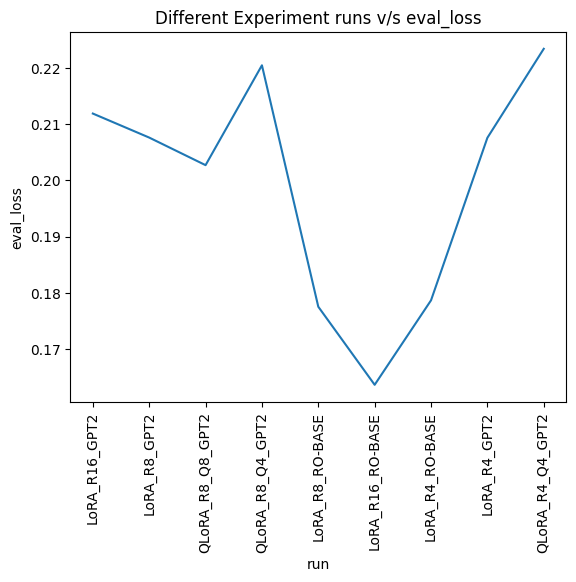

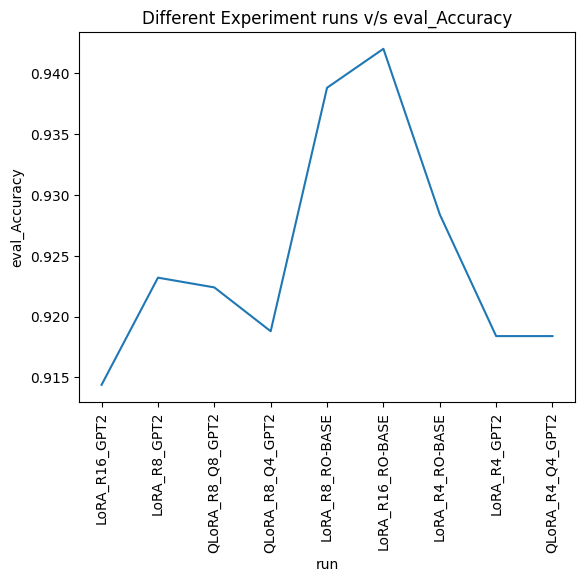

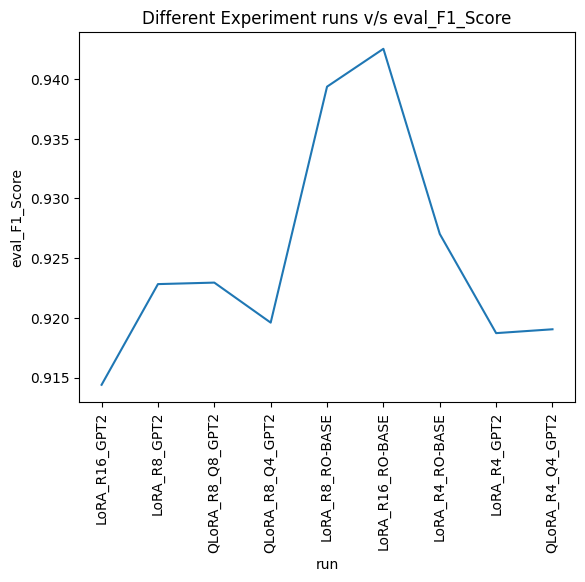

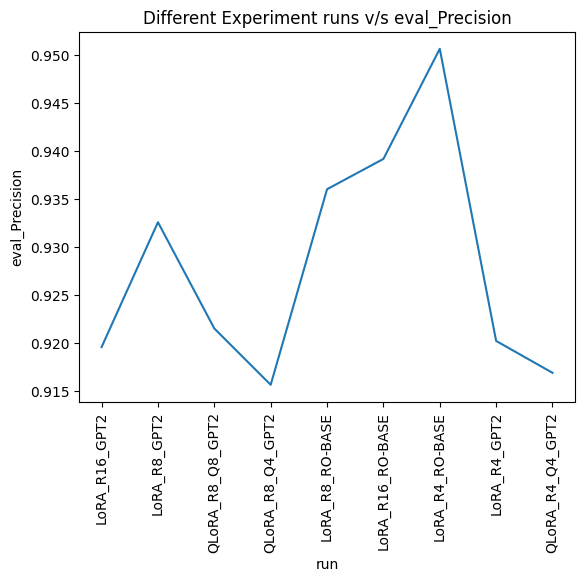

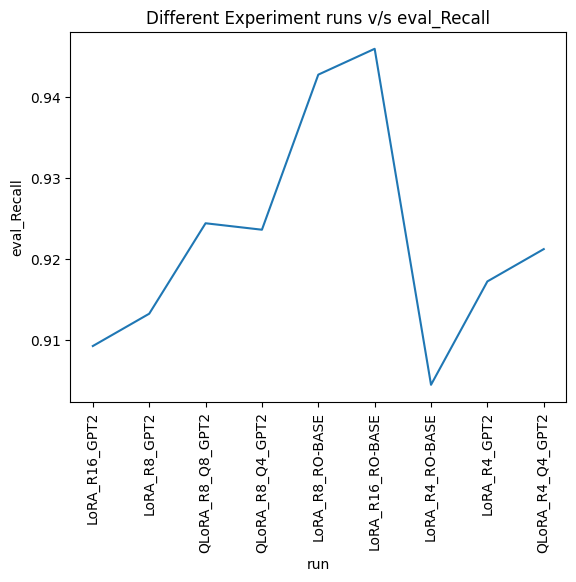

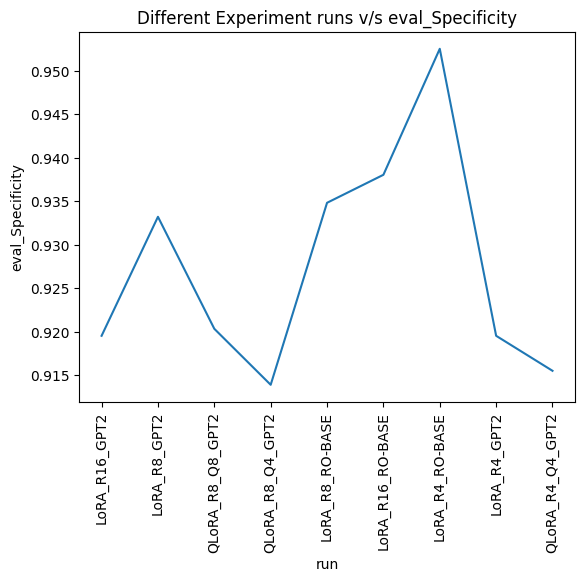

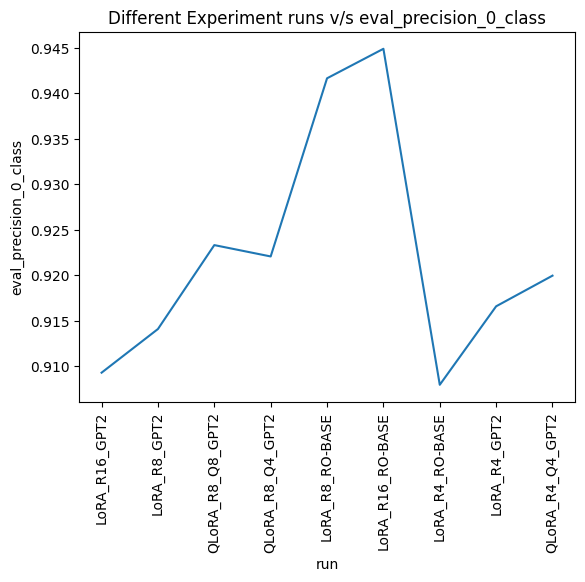

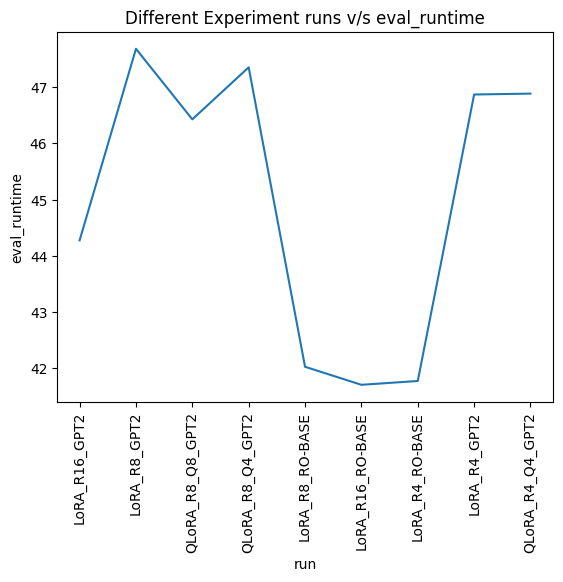

In [29]:
for col in list_y:
    sns.lineplot(x='run', y=col,data=df_infer)
    plt.xticks(rotation=90)
    plt.title(f'Different Experiment runs v/s {col}')
    plt.show()

### As can be seen in above plots, overall LoRA_R16_RO-BASE Experiment model seems to be the best performing model. LoRA_R16_RO-BASE also shows top performance in Specificity and Precision. LoRA_R16_RO-BASE has the lowest eval run time and loss and seems to be most accurate and best performing model. Overall Roberta based LoRA variants beats all GPT2 based LoRA and QLoRA variants.

In [34]:
list_paths = df_infer['model_path'].tolist()
list_paths

['./peft_gpt2_LoRA_imdb_0611232402_saved',
 './peft_gpt2_LoRA_imdb_0648252402_saved',
 './peft_gpt2_QLoRA_imdb_0726382402_saved',
 './peft_gpt2_QLoRA_imdb_0810132402_saved',
 './peft_roberta-base_LoRA_imdb_0841512402_saved',
 './peft_roberta-base_LoRA_imdb_0857172402_saved',
 './peft_roberta-base_LoRA_imdb_0920022402_saved',
 './peft_gpt2_LoRA_imdb_0934532402_saved',
 './peft_gpt2_QLoRA_imdb_0956482402_saved']

In [44]:
import os

In [54]:
fs = []
for paths in list_paths:
    fs.append(round(os.path.getsize(paths+"/adapter_model.safetensors")/(1024*1024), 2))

In [55]:
fs

[2.26, 1.13, 1.13, 1.13, 3.39, 4.52, 2.83, 0.57, 0.57]

In [56]:
df_infer['Weights File Size(MB)'] = fs

In [57]:
df_infer

,Unnamed: 0,eval_loss,eval_Accuracy,eval_F1_Score,eval_Precision,eval_Recall,eval_Specificity,eval_precision_0_class,eval_runtime,eval_samples_per_second,eval_steps_per_second,run,model_path,Weights File Size(MB)
0,0,0.211931,0.9144,0.914400,0.919549,0.909308,0.919549,0.909308,44.2772,56.463,7.069,LoRA_R16_GPT2,./peft_gpt2_LoRA_imdb_0611232402_saved,2.26
1,0,0.207649,0.9232,0.922830,0.932575,0.913286,0.933226,0.914106,47.6834,52.429,6.564,LoRA_R8_GPT2,./peft_gpt2_LoRA_imdb_0648252402_saved,1.13
2,0,0.202733,0.9224,0.922955,0.921491,0.924423,0.920354,0.923325,46.4293,53.845,6.741,QLoRA_R8_Q8_GPT2,./peft_gpt2_QLoRA_imdb_0726382402_saved,1.13
3,0,0.220531,0.9188,0.919604,0.915615,0.923628,0.913918,0.922078,47.3542,52.794,6.610,QLoRA_R8_Q4_GPT2,./peft_gpt2_QLoRA_imdb_0810132402_saved,1.13
4,0,0.177499,0.9388,0.939358,0.936019,0.942721,0.934835,0.941653,42.0294,59.482,7.447,LoRA_R8_RO-BASE,./peft_roberta-base_LoRA_imdb_0841512402_saved,3.39
5,0,0.163585,0.9420,0.942529,0.939179,0.945903,0.938053,0.944895,41.7091,59.939,7.504,LoRA_R16_RO-BASE,./peft_roberta-base_LoRA_imdb_0857172402_saved,4.52
6,0,0.178641,0.9284,0.927028,0.950669,0.904535,0.952534,0.907975,41.7769,59.842,7.492,LoRA_R4_RO-BASE,./peft_roberta-base_LoRA_imdb_0920022402_saved,2.83
7,0,0.207609,0.9184,0.918725,0.920192,0.917263,0.919549,0.916600,46.8707,53.338,6.678,LoRA_R4_GPT2,./peft_gpt2_LoRA_imdb_0934532402_saved,0.57
8,0,0.223472,0.9184,0.919048,0.916865,0.921241,0.915527,0.919968,46.8867,53.320,6.676,QLoRA_R4_Q4_GPT2,./peft_gpt2_QLoRA_imdb_0956482402_saved,0.57


#### As can be seen from output above lora adapters for Roberta based LoRA variants have largest file size. Rank 4 LoRA and QLoRA variants of GPT2 have the lowest lora adapter weights though with few degrees lower performance.

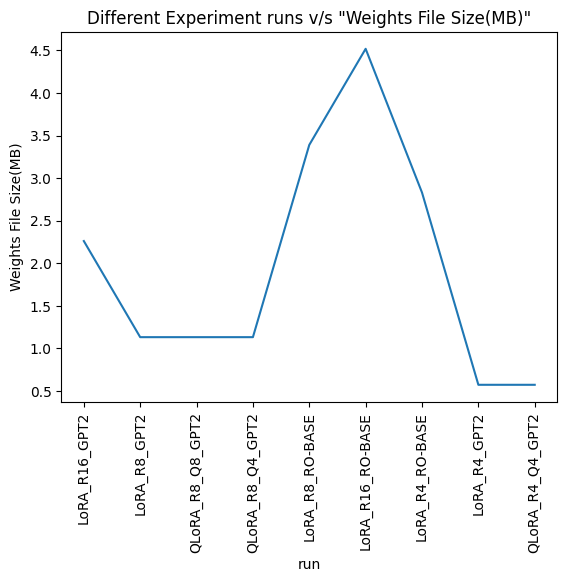

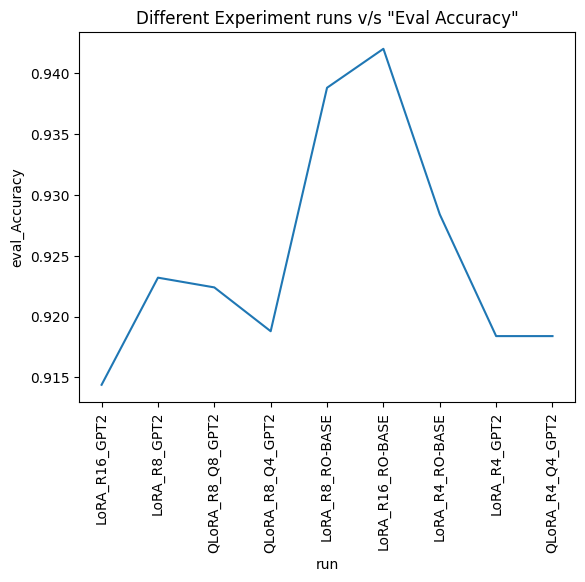

In [64]:
sns.lineplot(x='run', y='Weights File Size(MB)',data=df_infer)
plt.xticks(rotation=90)
plt.title(f'Different Experiment runs v/s "Weights File Size(MB)"')
plt.show()

sns.lineplot(x='run', y='eval_Accuracy',data=df_infer)
plt.xticks(rotation=90)
plt.title(f'Different Experiment runs v/s "Eval Accuracy"')
plt.show()

In [5]:
## Backing up the files

In [2]:
!ls -ltr

total 1160
drwxr-xr-x 2 student student    4096 Feb 23 12:52 tmp_trainer
-rw-r--r-- 1 student student    2242 Feb 24 11:17 Valid_Stats.csv
-rw-r--r-- 1 student student    2226 Feb 24 11:17 Test_Stats.csv
-rw-r--r-- 1 student student    1974 Feb 24 14:20 Infer_Stats.csv
drwxr-xr-x 4 student student    4096 Feb 24 16:48 peft_roberta-base_LoRA_imdb_0857172402
drwxr-xr-x 2 student student    4096 Feb 24 16:52 peft_gpt2_QLoRA_imdb_0810132402_saved
drwxr-xr-x 4 student student    4096 Feb 24 16:52 peft_roberta-base_LoRA_imdb_0920022402
drwxr-xr-x 2 student student    4096 Feb 24 16:52 peft_roberta-base_LoRA_imdb_0857172402_saved
drwxr-xr-x 4 student student    4096 Feb 24 16:52 peft_gpt2_LoRA_imdb_0934532402
drwxr-xr-x 4 student student    4096 Feb 24 16:52 peft_gpt2_QLoRA_imdb_0956482402
drwxr-xr-x 4 student student    4096 Feb 24 16:52 peft_roberta-base_LoRA_imdb_0841512402
drwxr-xr-x 2 student student    4096 Feb 24 16:52 peft_gpt2_LoRA_imdb_0611232402_saved
drwxr-xr-x 2 student student  

In [7]:
!tar cvf peft_tuning.tar ./peft* ./*.csv ./LightweightFineTuning_v9.ipynb

./peft_gpt2_LoRA_imdb_0611232402/
./peft_gpt2_LoRA_imdb_0611232402/checkpoint-3126/
./peft_gpt2_LoRA_imdb_0611232402/checkpoint-3126/tokenizer_config.json
./peft_gpt2_LoRA_imdb_0611232402/checkpoint-3126/special_tokens_map.json
./peft_gpt2_LoRA_imdb_0611232402/checkpoint-3126/merges.txt
./peft_gpt2_LoRA_imdb_0611232402/checkpoint-3126/optimizer.pt
./peft_gpt2_LoRA_imdb_0611232402/checkpoint-3126/adapter_model.safetensors
./peft_gpt2_LoRA_imdb_0611232402/checkpoint-3126/rng_state.pth
./peft_gpt2_LoRA_imdb_0611232402/checkpoint-3126/adapter_config.json
./peft_gpt2_LoRA_imdb_0611232402/checkpoint-3126/tokenizer.json
./peft_gpt2_LoRA_imdb_0611232402/checkpoint-3126/scheduler.pt
./peft_gpt2_LoRA_imdb_0611232402/checkpoint-3126/README.md
./peft_gpt2_LoRA_imdb_0611232402/checkpoint-3126/trainer_state.json
./peft_gpt2_LoRA_imdb_0611232402/checkpoint-3126/training_args.bin
./peft_gpt2_LoRA_imdb_0611232402/checkpoint-3126/vocab.json
./peft_gpt2_LoRA_imdb_0611232402/checkpoint-1563/
./peft_gpt2_L

./peft_gpt2_QLoRA_imdb_0726382402/checkpoint-1563/optimizer.pt
./peft_gpt2_QLoRA_imdb_0726382402/checkpoint-1563/adapter_model.safetensors
./peft_gpt2_QLoRA_imdb_0726382402/checkpoint-1563/rng_state.pth
./peft_gpt2_QLoRA_imdb_0726382402/checkpoint-1563/adapter_config.json
./peft_gpt2_QLoRA_imdb_0726382402/checkpoint-1563/tokenizer.json
./peft_gpt2_QLoRA_imdb_0726382402/checkpoint-1563/scheduler.pt
./peft_gpt2_QLoRA_imdb_0726382402/checkpoint-1563/README.md
./peft_gpt2_QLoRA_imdb_0726382402/checkpoint-1563/trainer_state.json
./peft_gpt2_QLoRA_imdb_0726382402/checkpoint-1563/training_args.bin
./peft_gpt2_QLoRA_imdb_0726382402/checkpoint-1563/vocab.json
./peft_gpt2_QLoRA_imdb_0726382402_saved/
./peft_gpt2_QLoRA_imdb_0726382402_saved/tokenizer_config.json
./peft_gpt2_QLoRA_imdb_0726382402_saved/special_tokens_map.json
./peft_gpt2_QLoRA_imdb_0726382402_saved/merges.txt
./peft_gpt2_QLoRA_imdb_0726382402_saved/adapter_model.safetensors
./peft_gpt2_QLoRA_imdb_0726382402_saved/adapter_config.js

./peft_roberta-base_LoRA_imdb_0841512402_saved/adapter_config.json
./peft_roberta-base_LoRA_imdb_0841512402_saved/tokenizer.json
./peft_roberta-base_LoRA_imdb_0841512402_saved/README.md
./peft_roberta-base_LoRA_imdb_0841512402_saved/training_args.bin
./peft_roberta-base_LoRA_imdb_0841512402_saved/vocab.json
./peft_roberta-base_LoRA_imdb_0857172402/
./peft_roberta-base_LoRA_imdb_0857172402/checkpoint-3126/
./peft_roberta-base_LoRA_imdb_0857172402/checkpoint-3126/tokenizer_config.json
./peft_roberta-base_LoRA_imdb_0857172402/checkpoint-3126/special_tokens_map.json
./peft_roberta-base_LoRA_imdb_0857172402/checkpoint-3126/merges.txt
./peft_roberta-base_LoRA_imdb_0857172402/checkpoint-3126/optimizer.pt
./peft_roberta-base_LoRA_imdb_0857172402/checkpoint-3126/adapter_model.safetensors
./peft_roberta-base_LoRA_imdb_0857172402/checkpoint-3126/rng_state.pth
./peft_roberta-base_LoRA_imdb_0857172402/checkpoint-3126/adapter_config.json
./peft_roberta-base_LoRA_imdb_0857172402/checkpoint-3126/token

In [8]:
!ls -lh peft_tuning.tar

-rw-r--r-- 1 student student 212M Feb 24 16:45 peft_tuning.tar
